# Credit Card Fraud Detection — Cross-Validation, Tuning, Scaling, Imbalance & Threshold Analysis

**CodSoft Data Science Internship — Task 5: Credit Card Fraud Detection**
(local folder `Task3_Credit_Card_Fraud_Detection`, my own project numbering)

**Phase 4 — model selection.** Every decision in this notebook — scaling, imbalance strategy,
hyperparameters, decision threshold, candidate model — is made with **stratified 5-fold
cross-validation on the training split only**. The test split is locked in section 3 and is not
used again until the isolation check in section 16. No test metric, test prediction or test
probability is produced anywhere in this notebook.

The outcome is a **CANDIDATE FINAL MODEL** and a **CANDIDATE OPERATING THRESHOLD**. Neither is final
until Phase 5 evaluates it once on the untouched test set. No model is persisted.

---
## 1. Phase 4 Introduction

Phase 3 recorded ten baseline configurations on the holdout set. Those numbers remain a useful
historical record, but they cannot be used to choose between configurations: doing so would turn
the test set into a tuning set and bias the final estimate. Phase 4 therefore re-asks every
selection question on the training data alone.

| Question | Where answered |
|---|---|
| Which scaling strategy (`standard` / `minimal` / `log_amount`)? | section 5 |
| Which imbalance strategy, for each model family? | section 6 |
| How do logistic regression and random forest validate under CV? | sections 7–8 |
| Which hyperparameters? | section 9 |
| What does the precision/recall trade-off look like out-of-fold? | section 10 |
| Is 0.5 a sensible threshold? If not, what is? | section 11 |
| How stable are the leading configurations across folds? | section 12 |
| How large is the train/validation gap? | section 13 |
| Which configuration becomes the candidate, and why? | sections 14–15 |
| Was the test set really left alone? | section 16 |

---
## 2. Model Selection Rules — declared before any result is computed

These rules are written here, and implemented in code below, **before** a single cross-validation
score exists. The selections later in the notebook are computed by these rules, not chosen by eye.

**Rule 1 — primary metric.** Configurations are compared on **mean CV PR-AUC** (average precision,
computed from predicted probabilities, fraud as the positive class). Not accuracy — Phase 1 showed an
always-legitimate model scores 99.83%. Not ROC-AUC — Phase 3 showed it ranked the configurations
almost in reverse of PR-AUC.

**Rule 2 — one-standard-error rule** (Hastie, Tibshirani & Friedman, *The Elements of Statistical
Learning*, §7.10; Breiman et al., *CART*, 1984). Let the best configuration have mean PR-AUC `m` and
standard error `se = std / √5`. Every configuration with mean PR-AUC ≥ `m − se` is treated as
statistically indistinguishable from the best, and **the simplest of them is chosen**. This is not a
weighted score: PR-AUC alone decides who is eligible, and a fixed, declared ordering decides among
the eligible.

**Declared simplicity ordering** (lower is simpler; compared left to right):

| Dimension | Order |
|---|---|
| Model family | logistic regression < random forest |
| Imbalance handling | original = class weights (no rows changed) < undersampling < oversampling < SMOTE |
| Ensemble size | fewer trees < more trees |
| Scaling | `standard` (the Phase 2/3 default — no change) < `minimal` < `log_amount` (extra non-linear step) |

Final tie-break among equally simple configurations: higher mean PR-AUC.

**Rule 3 — candidate operating threshold.** Chosen on **out-of-fold training predictions only**, from
the grid 0.05, 0.10, …, 0.95, as the threshold with the **maximum F1**; ties go to the **lower**
threshold (favouring recall — a missed fraud is usually the costlier error). F1 is used because the
dataset contains no cost model; it is the transparent default that balances missed fraud against
false alarms. If the maximum lands on a grid edge, the grid is extended toward that edge in 0.01
steps and the result is flagged.

**Rule 4 — the test set is locked.** No test row may be predicted, scored, resampled or used to fit
any transformer in this notebook. Section 16 verifies this three independent ways.

In [1]:
import hashlib
import json
import platform
import sys
import time
import warnings
from pathlib import Path

NOTEBOOK_START = time.perf_counter()
NOTEBOOK_START_WALL = time.time()   # artefact check: only files written by THIS notebook count

import imblearn
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from matplotlib.lines import Line2D
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import GridSearchCV

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["grid.alpha"] = 0.3

# Colour roles, unchanged from Phase 3: class colours are never reused for anything else.
C_LEGIT, C_FRAUD = "#3b5bdb", "#e8590c"
STRATEGY_STYLE = {
    "original":     {"color": "#495057", "ls": "-",  "marker": "o"},
    "class_weight": {"color": "#4a3aa7", "ls": "--", "marker": "s"},
    "oversample":   {"color": "#0ca678", "ls": "-.", "marker": "^"},
    "smote":        {"color": "#e8a100", "ls": ":",  "marker": "D"},
    "undersample":  {"color": "#c2255c", "ls": (0, (5, 1, 1, 1)), "marker": "v"},
}
# Finalist colours - validated pair (all checks pass), used only in finalist-only figures.
FINALIST_COLOR = {"logistic_regression": "#087f5b", "random_forest": "#9c36b5"}
MODEL_MARKER = {"logistic_regression": "o", "random_forest": "s"}
SHORT = {"original": "original", "class_weight": "class weights", "oversample": "oversampling",
         "smote": "SMOTE", "undersample": "undersampling"}

print("python          ", sys.version.split()[0])
print("pandas          ", pd.__version__)
print("numpy           ", np.__version__)
print("scipy           ", scipy.__version__)
print("scikit-learn    ", sklearn.__version__)
print("imbalanced-learn", imblearn.__version__)
print("matplotlib      ", matplotlib.__version__)
print("seaborn         ", sns.__version__)
print("platform        ", platform.system(), platform.release())

python           3.13.0
pandas           3.0.6
numpy            2.5.3
scipy            1.18.1
scikit-learn     1.9.1
imbalanced-learn 0.14.2
matplotlib       3.11.2
seaborn          0.13.2
platform         Windows 11


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "dataset").is_dir() else NOTEBOOK_DIR.parent
NOTEBOOK_PATH = PROJECT_DIR / "notebooks" / "04_model_validation_tuning.ipynb"
VIZ_DIR = PROJECT_DIR / "visualizations"
RESULTS_DIR = PROJECT_DIR / "results"
VIZ_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
if str(PROJECT_DIR / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR / "src"))

import data_preprocessing as dp
import model_training as mt

RANDOM_STATE = mt.RANDOM_STATE
print("RANDOM_STATE     :", RANDOM_STATE)
print("N_SPLITS         :", mt.N_SPLITS)
print("threshold grid   :", mt.THRESHOLD_GRID[0], "...", mt.THRESHOLD_GRID[-1], f"({len(mt.THRESHOLD_GRID)} values)")

RANDOM_STATE     : 42
N_SPLITS         : 5
threshold grid   : 0.05 ... 0.95 (19 values)


In [3]:
# Rules 2 and 3 as code - defined before any result exists.
FAMILY_RANK = {"logistic_regression": 0, "random_forest": 1}
IMBALANCE_RANK = {"original": 0, "class_weight": 0, "undersample": 1, "oversample": 2, "smote": 3}
SCALING_RANK = {"standard": 0, "minimal": 1, "log_amount": 2}


def one_se_choice(table: pd.DataFrame) -> tuple:
    """Rule 2. `table` has one row per configuration with pr_auc_mean, pr_auc_std and the
    complexity columns family_rank, imbalance_rank, n_estimators, scaling_rank."""
    best_key = table["pr_auc_mean"].idxmax()
    best_mean = table.loc[best_key, "pr_auc_mean"]
    se = table.loc[best_key, "pr_auc_std"] / np.sqrt(mt.N_SPLITS)
    eligible = table[table["pr_auc_mean"] >= best_mean - se].copy()
    eligible = eligible.sort_values(["family_rank", "imbalance_rank", "n_estimators", "scaling_rank", "pr_auc_mean"],
                                    ascending=[True, True, True, True, False], kind="stable")
    return eligible.index[0], best_key, se, eligible


def choose_threshold(y_true, proba) -> tuple:
    """Rule 3, including the declared grid-edge extension."""
    grid = list(mt.THRESHOLD_GRID)
    table = mt.threshold_table(y_true, proba, grid)
    chosen = mt.select_threshold_max_f1(table)
    edge = None
    if chosen == grid[-1]:
        edge = "upper"
        grid = grid + [0.96, 0.97, 0.98, 0.99]
    elif chosen == grid[0]:
        edge = "lower"
        grid = [0.01, 0.02, 0.03, 0.04] + grid
    if edge:
        table = mt.threshold_table(y_true, proba, grid)
        chosen = mt.select_threshold_max_f1(table)
    return chosen, table, edge


print("selection rules defined: one_se_choice (Rule 2), choose_threshold (Rule 3)")

selection rules defined: one_se_choice (Rule 2), choose_threshold (Rule 3)


---
## 3. Training Data Only — the test set is locked here

The Phase 2 split is reproduced (not re-drawn) and verified against its documented counts. The test
set is then fingerprinted with **the same function Phase 3 used**, compared against the fingerprint
Phase 3 recorded, and **removed from the notebook's namespace**. Only its row *labels* are kept, for
the isolation checks in section 16.

This is the only code cell before section 16 that touches the test split. Section 16 verifies that by
reading this notebook's own source.

In [4]:
# TEST-ISOLATION CELL - the only place before section 16 where the test split is referenced.
SHA256_INITIAL = dp.sha256_of_file(dp.default_dataset_path())
assert SHA256_INITIAL == dp.RAW_DATASET_SHA256, "raw dataset checksum mismatch - STOP"

df = dp.load_data()
split = dp.split_data(df)


def frame_fingerprint(X: pd.DataFrame, y: pd.Series) -> str:
    """Identical to the Phase 3 fingerprint function."""
    digest = hashlib.sha256()
    digest.update(np.ascontiguousarray(X.index.to_numpy()).tobytes())
    digest.update(np.ascontiguousarray(X.to_numpy()).tobytes())
    digest.update(np.ascontiguousarray(y.to_numpy()).tobytes())
    return digest.hexdigest()


PHASE3_TEST_FINGERPRINT = "50a7a7a9ab2a1efdb5ed371e35593bd19f04a3276b08ce31ef3a51017187f27e"
TEST_FINGERPRINT_LOCK = frame_fingerprint(split.X_test, split.y_test)
TEST_INDEX = split.X_test.index.copy()                   # labels only - for isolation checks
TEST_COUNTS_LOCK = split.y_test.value_counts().sort_index().to_dict()
TEST_ROWS_LOCK = len(split.X_test)

X_train, y_train = split.X_train, split.y_train
TRAIN_INDEX = X_train.index.copy()
del split, df                                          # the test frames leave the namespace here

checks_lock = {
    "raw checksum": SHA256_INITIAL == dp.RAW_DATASET_SHA256,
    "train rows 226,980": len(X_train) == 226_980,
    "train legitimate 226,602": int((y_train == 0).sum()) == 226_602,
    "train fraudulent 378": int((y_train == 1).sum()) == 378,
    "test rows 56,746": TEST_ROWS_LOCK == 56_746,
    "test counts 56,651 / 95": TEST_COUNTS_LOCK == {0: 56_651, 1: 95},
    "test fingerprint = Phase 3 record": TEST_FINGERPRINT_LOCK == PHASE3_TEST_FINGERPRINT,
    "train/test labels disjoint": len(TRAIN_INDEX.intersection(TEST_INDEX)) == 0,
}
for name, ok in checks_lock.items():
    print(f"{name:<36}: {'OK' if ok else 'FAILED'}")
assert all(checks_lock.values()), "Phase 2 split not reproduced - STOP"
print()
print("test fingerprint:", TEST_FINGERPRINT_LOCK)
print("test split locked: frames deleted from the namespace; only row labels retained")

raw checksum                        : OK
train rows 226,980                  : OK
train legitimate 226,602            : OK
train fraudulent 378                : OK
test rows 56,746                    : OK
test counts 56,651 / 95             : OK
test fingerprint = Phase 3 record   : OK
train/test labels disjoint          : OK

test fingerprint: 50a7a7a9ab2a1efdb5ed371e35593bd19f04a3276b08ce31ef3a51017187f27e
test split locked: frames deleted from the namespace; only row labels retained


---
## 4. Cross-Validation Strategy

`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` on the **training split only**. One
splitter object is shared by every experiment, so every configuration is scored on exactly the same
five folds — differences between configurations are not confounded with differences between folds.

Inside each fold, the whole pipeline — scaler, resampler, classifier — is cloned and fitted from
scratch on that fold's training rows. The validation fold is never resampled and keeps its natural
fraud rate:

```
fold training rows  ->  preprocess (fit)  ->  resample / weight (fit)  ->  classifier (fit)
fold validation rows ->  preprocess (transform only)  ->  classifier (predict)  ->  metrics
```

In [5]:
cv = mt.make_cv()
folds = mt.fold_table(cv, X_train, y_train)
print("StratifiedKFold:", cv)
folds.style.format({"train rows": "{:,}", "validation rows": "{:,}", "train fraud %": "{:.4f}%",
                    "validation fraud %": "{:.4f}%"})

StratifiedKFold: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


,train rows,validation rows,train fraud,validation fraud,train fraud %,validation fraud %,overlap
fold,,,,,,,
1,"181,584","45,396",303,75,0.1669%,0.1652%,0
2,"181,584","45,396",303,75,0.1669%,0.1652%,0
3,"181,584","45,396",302,76,0.1663%,0.1674%,0
4,"181,584","45,396",302,76,0.1663%,0.1674%,0
5,"181,584","45,396",302,76,0.1663%,0.1674%,0


In [6]:
fold_assignment = np.zeros(len(X_train), dtype=int)
for fold, (_, valid_idx) in enumerate(cv.split(X_train, y_train), start=1):
    fold_assignment[valid_idx] += fold
counts_per_row = np.zeros(len(X_train), dtype=int)
for _, valid_idx in cv.split(X_train, y_train):
    counts_per_row[valid_idx] += 1

FOLD_FINGERPRINT = hashlib.sha256(fold_assignment.tobytes()).hexdigest()
print("every training row in exactly one validation fold:", bool((counts_per_row == 1).all()))
print("no train/validation overlap in any fold          :", bool((folds["overlap"] == 0).all()))
print("validation fraud per fold                        :", folds["validation fraud"].tolist(),
      "(sum", int(folds["validation fraud"].sum()), ")")
print("fold-assignment fingerprint                      :", FOLD_FINGERPRINT[:32])

every training row in exactly one validation fold: True
no train/validation overlap in any fold          : True
validation fraud per fold                        : [75, 75, 76, 76, 76] (sum 378 )
fold-assignment fingerprint                      : 30b0865aacf0b2d4a312088a9efd9396


In [7]:
# Bookkeeping shared by every experiment below.
cv_results = {}          # name -> mt.CVResult
config_meta = {}         # name -> dict(model, scaling, strategy, n_estimators, params)


def run_cv(name, model, strategy, scaling="standard", classifier_params=None):
    """Cross-validate one configuration on the training split and record it."""
    pipe = mt.build_pipeline(model, strategy, scaling=scaling, classifier_params=classifier_params)
    result = mt.cross_validate_pipeline(name, pipe, X_train, y_train, cv)
    cv_results[name] = result
    params = pipe.named_steps["classifier"].get_params()
    config_meta[name] = {"model": model, "scaling": scaling, "strategy": strategy,
                         "n_estimators": params.get("n_estimators", 0) if model == "random_forest" else 0,
                         "classifier_params": dict(classifier_params or {})}
    s = result.summary()
    warn = f"  warnings: {len(result.warnings)}" if result.warnings else ""
    print(f"{name:<52} PR-AUC {s['pr_auc_mean']:.4f} ± {s['pr_auc_std']:.4f} | "
          f"recall {s['recall_mean']:.4f} | precision {s['precision_mean']:.4f} | "
          f"fit {sum(result.fit_seconds):6.1f}s{warn}")
    return result


def summary_table(names):
    rows = []
    for n in names:
        s = cv_results[n].summary()
        m = config_meta[n]
        rows.append({"configuration": n, "model": mt.MODEL_LABELS[m["model"]], "scaling": m["scaling"],
                     "imbalance": mt.STRATEGY_LABELS[m["strategy"]],
                     **{k: s[k] for k in ("pr_auc_mean", "pr_auc_std", "precision_mean", "precision_std",
                                          "recall_mean", "recall_std", "f1_mean", "f1_std",
                                          "roc_auc_mean", "roc_auc_std")},
                     "fit s (5 folds)": sum(cv_results[n].fit_seconds),
                     "family_rank": FAMILY_RANK[m["model"]], "imbalance_rank": IMBALANCE_RANK[m["strategy"]],
                     "n_estimators": m["n_estimators"], "scaling_rank": SCALING_RANK[m["scaling"]]})
    return pd.DataFrame(rows).set_index("configuration")


DISPLAY_COLS = ["model", "scaling", "imbalance", "pr_auc_mean", "pr_auc_std", "precision_mean", "recall_mean",
                "f1_mean", "roc_auc_mean", "fit s (5 folds)"]
print("helpers ready")

helpers ready


---
## 5. Scaling Strategy Comparison

Phase 2 implemented three preprocessors and deferred the choice. It is made here, on training CV.

**Logistic regression:** all three scalings × all five imbalance strategies = 15 configurations,
75 fits, default hyperparameters. Logistic regression is cheap (well under a second per fold), so the
full cross is affordable and nothing is assumed.

**Random forest:** a decision tree splits on *order* — "is `Amount` ≤ t?" — and every Phase 2 scaling
is a strictly increasing transform of each column (`StandardScaler` is affine with positive scale;
`log1p` is monotone). **In exact arithmetic**, the same partitions of the training rows are therefore
available under every scaling. Two practical details break *exact* invariance, and they are stated
here rather than discovered later:

1. **Column order.** `minimal` emits its columns as `Time, Amount, V1…V28`; `standard` and `log_amount`
   keep `Time, V1…V28, Amount`. A forest draws each split's random feature subset **by column index**,
   so the same seed picks different features once the order changes — the trees differ.
2. **float32.** scikit-learn casts features to float32 before growing trees. Rounding after a transform
   can make two nearly equal values collide (or separate), which can change which split point wins.

So the real question for the forest is not "identical?" but "**does scaling change performance by a
material amount?**" — section 8 answers that with Rule 2. SMOTE is a separate case: it interpolates
between *nearest neighbours*, a distance computation that scaling changes by design, so it is tested
separately if SMOTE is the forest's strategy.

In [8]:
LR_SCALING_NAMES = {}
for scaling in ("standard", "minimal", "log_amount"):
    for strategy in mt.STRATEGIES:
        name = f"LR | {scaling} | {SHORT[strategy]}"
        LR_SCALING_NAMES[(scaling, strategy)] = name
        run_cv(name, "logistic_regression", strategy, scaling=scaling)

LR | standard | original                             PR-AUC 0.7527 ± 0.0364 | recall 0.6056 | precision 0.8633 | fit    3.2s


LR | standard | class weights                        PR-AUC 0.7382 ± 0.0294 | recall 0.9179 | precision 0.0605 | fit    6.3s


LR | standard | oversampling                         PR-AUC 0.7387 ± 0.0290 | recall 0.9153 | precision 0.0609 | fit   10.6s


LR | standard | SMOTE                                PR-AUC 0.7431 ± 0.0306 | recall 0.9073 | precision 0.0550 | fit   12.1s


LR | standard | undersampling                        PR-AUC 0.5715 ± 0.1286 | recall 0.9126 | precision 0.0430 | fit    1.3s


...

LR | log_amount | original                           PR-AUC 0.7543 ± 0.0369 | recall 0.6084 | precision 0.8699 | fit    3.3s


LR | log_amount | class weights                      PR-AUC 0.7366 ± 0.0279 | recall 0.9126 | precision 0.0591 | fit    4.9s


LR | log_amount | oversampling                       PR-AUC 0.7366 ± 0.0278 | recall 0.9100 | precision 0.0591 | fit    7.9s


LR | log_amount | SMOTE                              PR-AUC 0.7399 ± 0.0281 | recall 0.9073 | precision 0.0544 | fit    8.6s


LR | log_amount | undersampling                      PR-AUC 0.5788 ± 0.1345 | recall 0.9153 | precision 0.0429 | fit    1.7s


In [9]:
lr_grid = summary_table(list(LR_SCALING_NAMES.values()))
print("TRAINING-ONLY 5-FOLD CV - logistic regression, default hyperparameters, threshold 0.5")
lr_grid[DISPLAY_COLS]

TRAINING-ONLY 5-FOLD CV - logistic regression, default hyperparameters, threshold 0.5


,model,scaling,imbalance,pr_auc_mean,pr_auc_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit s (5 folds)
configuration,,,,,,,,,,
LR | standard | original,Logistic Regression,standard,Original distribution,0.752709,0.036378,0.863288,0.605649,0.709644,0.977743,3.231469
LR | standard | class weights,Logistic Regression,standard,Class weights (balanced),0.738234,0.029436,0.060535,0.917895,0.113481,0.981446,6.255020
LR | standard | oversampling,Logistic Regression,standard,Random oversampling,0.738726,0.029007,0.060884,0.915263,0.114077,0.981463,10.589938
LR | standard | SMOTE,Logistic Regression,standard,SMOTE,0.743121,0.030637,0.054983,0.907298,0.103630,0.980903,12.117457
LR | standard | undersampling,Logistic Regression,standard,Random undersampling,0.571517,0.128634,0.043027,0.912632,0.082116,0.980230,1.339789
LR | minimal | original,Logistic Regression,minimal,Original distribution,0.754779,0.034514,0.863714,0.608316,0.711742,0.976966,3.069139
LR | minimal | class weights,Logistic Regression,minimal,Class weights (balanced),0.737951,0.029336,0.060564,0.917895,0.113530,0.981359,7.128649
LR | minimal | oversampling,Logistic Regression,minimal,Random oversampling,0.738252,0.029097,0.060705,0.915263,0.113765,0.981441,12.788004
LR | minimal | SMOTE,Logistic Regression,minimal,SMOTE,0.742734,0.031249,0.055930,0.907298,0.105289,0.980695,12.951107


In [10]:
pivot = lr_grid.pivot_table(index="imbalance", columns="scaling", values="pr_auc_mean")
pivot = pivot.loc[[mt.STRATEGY_LABELS[s] for s in mt.STRATEGIES], ["standard", "minimal", "log_amount"]]
pivot["best scaling"] = pivot.idxmax(axis=1)
pivot["spread (max-min)"] = pivot[["standard", "minimal", "log_amount"]].max(axis=1) - pivot[["standard", "minimal", "log_amount"]].min(axis=1)
se_by_strategy = lr_grid.groupby("imbalance")["pr_auc_std"].mean() / np.sqrt(mt.N_SPLITS)
pivot["typical SE"] = se_by_strategy.reindex(pivot.index)
print("Mean CV PR-AUC by scaling (rows = imbalance strategy)")
pivot

Mean CV PR-AUC by scaling (rows = imbalance strategy)


scaling,standard,minimal,log_amount,best scaling,spread (max-min),typical SE
imbalance,,,,,,
Original distribution,0.752709,0.754779,0.754255,minimal,0.002070,0.016072
Class weights (balanced),0.738234,0.737951,0.736637,standard,0.001597,0.012914
Random oversampling,0.738726,0.738252,0.736582,standard,0.002144,0.012808
SMOTE,0.743121,0.742734,0.739939,standard,0.003182,0.013421
Random undersampling,0.571517,0.591753,0.578824,minimal,0.020236,0.057677


In [11]:
# Rule 2 applied to the 15 logistic-regression configurations.
LR_SCALING_CHOICE, LR_SCALING_BEST, LR_SCALING_SE, lr_scaling_eligible = one_se_choice(lr_grid)
SELECTED_SCALING = config_meta[LR_SCALING_CHOICE]["scaling"]
print(f"highest mean CV PR-AUC      : {LR_SCALING_BEST}  ({lr_grid.loc[LR_SCALING_BEST, 'pr_auc_mean']:.6f})")
print(f"one standard error          : {LR_SCALING_SE:.6f}")
print(f"eligible (within 1 SE)      : {len(lr_scaling_eligible)} configurations")
print(f"Rule 2 choice               : {LR_SCALING_CHOICE}")
print()
print(f"SELECTED SCALING (for the model pipeline): {SELECTED_SCALING}")
lr_scaling_eligible[["pr_auc_mean", "pr_auc_std", "recall_mean", "precision_mean"]]

highest mean CV PR-AUC      : LR | minimal | original  (0.754779)
one standard error          : 0.015435
eligible (within 1 SE)      : 6 configurations
Rule 2 choice               : LR | standard | original

SELECTED SCALING (for the model pipeline): standard


,pr_auc_mean,pr_auc_std,recall_mean,precision_mean
configuration,,,,
LR | standard | original,0.752709,0.036378,0.605649,0.863288
LR | minimal | original,0.754779,0.034514,0.608316,0.863714
LR | log_amount | original,0.754255,0.036924,0.608351,0.869867
LR | standard | SMOTE,0.743121,0.030637,0.907298,0.054983
LR | minimal | SMOTE,0.742734,0.031249,0.907298,0.055930
LR | log_amount | SMOTE,0.739939,0.028141,0.907298,0.054401


**Reading the result.** Scaling makes almost no difference to logistic regression. For four of the five imbalance strategies, the three scalings are within **0.0016–0.0032** mean CV PR-AUC of each other, against a typical standard error of **0.013–0.016**. Only undersampling spreads further (**0.020**), and its own standard error (**0.058**) is almost three times that spread — it is unstable under every scaling, not sensitive to one.

* The highest mean belongs to `minimal` + original distribution (**0.754779**), but `standard` + original (**0.752709**) is only **0.0021** lower, well inside one standard error (**0.015435**). Six configurations are eligible under Rule 2 — the three original-distribution runs and the three SMOTE runs.
* **Rule 2 keeps `standard`**, the Phase 2/3 default, because nothing beats it by more than one standard error.
* `log_amount` does not help despite `Amount`'s skewness of 16.98. That is consistent with Phase 1: `Amount` has almost no linear association with `Class` (r = +0.0056), so reshaping it has little for a linear model to exploit.

**Selected scaling: `standard`** — chosen on training CV, not assumed.

### Visualisation 19 — scaling strategy comparison (logistic regression)

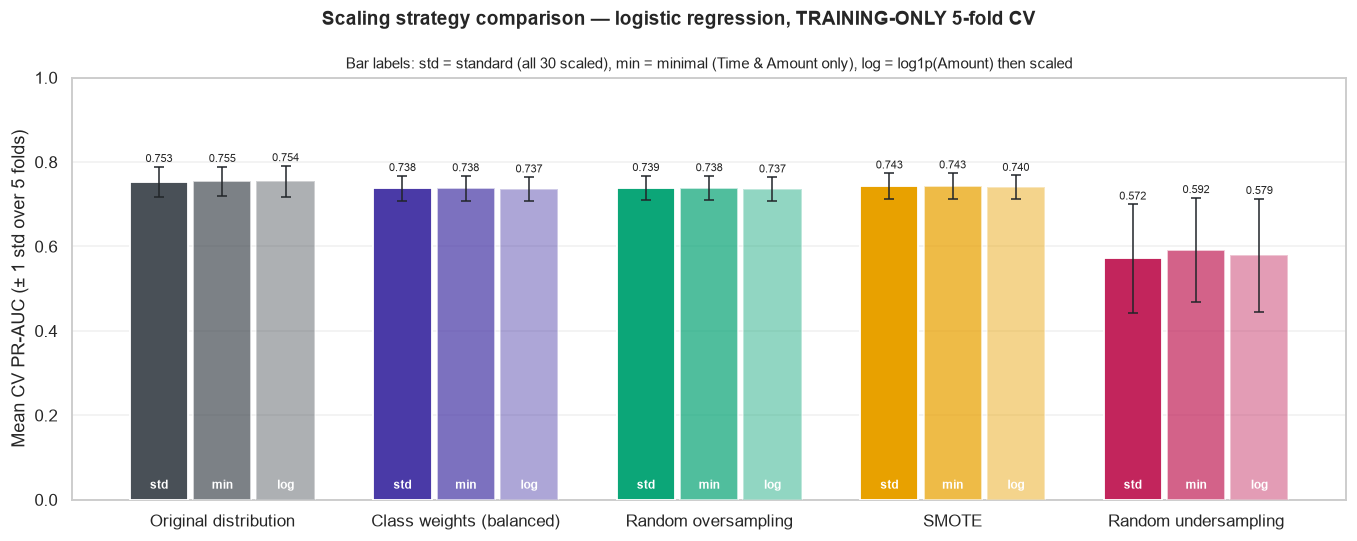

In [12]:
fig, ax = plt.subplots(figsize=(12.5, 5))
scalings = ["standard", "minimal", "log_amount"]
width = 0.26
for gi, strategy in enumerate(mt.STRATEGIES):
    for si, scaling in enumerate(scalings):
        s = cv_results[LR_SCALING_NAMES[(scaling, strategy)]].summary()
        x = gi + (si - 1) * width
        ax.bar(x, s["pr_auc_mean"], width=width * 0.92, color=STRATEGY_STYLE[strategy]["color"],
               alpha=[1.0, 0.72, 0.45][si], zorder=3, edgecolor="white", linewidth=1.2)
        ax.errorbar(x, s["pr_auc_mean"], yerr=s["pr_auc_std"], color="#212529", capsize=3, linewidth=1, zorder=4)
        ax.annotate(f"{s['pr_auc_mean']:.3f}", xy=(x, s["pr_auc_mean"] + s["pr_auc_std"]), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=7.5)
        ax.text(x, 0.02, {"standard": "std", "minimal": "min", "log_amount": "log"}[scaling],
                ha="center", va="bottom", fontsize=8, color="white", fontweight="bold", zorder=5)
ax.set_xticks(range(5), [mt.STRATEGY_LABELS[s] for s in mt.STRATEGIES])
ax.set_ylabel("Mean CV PR-AUC (± 1 std over 5 folds)")
ax.set_ylim(0, 1)
ax.set_title("Bar labels: std = standard (all 30 scaled), min = minimal (Time & Amount only), "
             "log = log1p(Amount) then scaled", fontsize=9.5, fontweight="normal")
ax.grid(axis="x", visible=False)
fig.suptitle("Scaling strategy comparison — logistic regression, TRAINING-ONLY 5-fold CV",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "19_scaling_strategy_comparison.png")
plt.show()

---
## 6. Imbalance Strategy Comparison

Five strategies, both model families, default hyperparameters. Logistic regression uses the scaling
selected in section 5; random forest uses `standard` (it is scale-invariant — tested in section 8).
Class weighting is `class_weight="balanced"`; every resampler sits inside the `imblearn` pipeline, so
it is re-fitted on each fold's training rows and never touches a validation fold.

In [13]:
LR_IMB_NAMES = {s: LR_SCALING_NAMES[(SELECTED_SCALING, s)] for s in mt.STRATEGIES}   # already run in section 5
RF_IMB_NAMES = {}
for strategy in mt.STRATEGIES:
    name = f"RF | standard | {SHORT[strategy]}"
    RF_IMB_NAMES[strategy] = name
    run_cv(name, "random_forest", strategy)

RF | standard | original                             PR-AUC 0.8341 ± 0.0350 | recall 0.7751 | precision 0.9427 | fit  285.1s


RF | standard | class weights                        PR-AUC 0.8347 ± 0.0307 | recall 0.7882 | precision 0.9211 | fit  114.5s


RF | standard | oversampling                         PR-AUC 0.8331 ± 0.0305 | recall 0.7777 | precision 0.9347 | fit  281.2s


RF | standard | SMOTE                                PR-AUC 0.8425 ± 0.0321 | recall 0.8227 | precision 0.8926 | fit  586.1s


RF | standard | undersampling                        PR-AUC 0.7579 ± 0.0595 | recall 0.8941 | precision 0.0696 | fit    2.6s


In [14]:
imbalance_table = summary_table(list(LR_IMB_NAMES.values()) + list(RF_IMB_NAMES.values()))
print("TRAINING-ONLY 5-FOLD CV - default hyperparameters, threshold 0.5")
imbalance_table[DISPLAY_COLS]

TRAINING-ONLY 5-FOLD CV - default hyperparameters, threshold 0.5


,model,scaling,imbalance,pr_auc_mean,pr_auc_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit s (5 folds)
configuration,,,,,,,,,,
LR | standard | original,Logistic Regression,standard,Original distribution,0.752709,0.036378,0.863288,0.605649,0.709644,0.977743,3.231469
LR | standard | class weights,Logistic Regression,standard,Class weights (balanced),0.738234,0.029436,0.060535,0.917895,0.113481,0.981446,6.255020
LR | standard | oversampling,Logistic Regression,standard,Random oversampling,0.738726,0.029007,0.060884,0.915263,0.114077,0.981463,10.589938
LR | standard | SMOTE,Logistic Regression,standard,SMOTE,0.743121,0.030637,0.054983,0.907298,0.103630,0.980903,12.117457
LR | standard | undersampling,Logistic Regression,standard,Random undersampling,0.571517,0.128634,0.043027,0.912632,0.082116,0.980230,1.339789
RF | standard | original,Random Forest,standard,Original distribution,0.834131,0.034962,0.942724,0.775088,0.848777,0.938858,285.119960
RF | standard | class weights,Random Forest,standard,Class weights (balanced),0.834693,0.030683,0.921052,0.788246,0.848139,0.959212,114.488597
RF | standard | oversampling,Random Forest,standard,Random oversampling,0.833136,0.030456,0.934691,0.777684,0.847559,0.949325,281.221163
RF | standard | SMOTE,Random Forest,standard,SMOTE,0.842494,0.032139,0.892634,0.822737,0.855322,0.973781,586.075442


In [15]:
# Rule 2 within each family: the imbalance strategy each family carries into tuning.
LR_IMB_CHOICE, LR_IMB_BEST, LR_IMB_SE, _ = one_se_choice(summary_table(list(LR_IMB_NAMES.values())))
RF_IMB_CHOICE, RF_IMB_BEST, RF_IMB_SE, rf_imb_eligible = one_se_choice(summary_table(list(RF_IMB_NAMES.values())))
RF_STRATEGY = config_meta[RF_IMB_CHOICE]["strategy"]

lr_ranked = summary_table(list(LR_IMB_NAMES.values())).sort_values("pr_auc_mean", ascending=False)
LR_TUNING_STRATEGIES = [config_meta[n]["strategy"] for n in lr_ranked.index[:2]]

print(f"LR  highest PR-AUC : {LR_IMB_BEST}   | Rule 2 choice: {LR_IMB_CHOICE}")
print(f"LR  strategies carried into tuning (top 2 by CV PR-AUC): {LR_TUNING_STRATEGIES}")
print(f"RF  highest PR-AUC : {RF_IMB_BEST}   | Rule 2 choice: {RF_IMB_CHOICE}")
print(f"RF  strategy carried into tuning: {RF_STRATEGY}")
print(f"RF  eligible within 1 SE ({RF_IMB_SE:.4f}):", list(rf_imb_eligible.index))

LR  highest PR-AUC : LR | standard | original   | Rule 2 choice: LR | standard | original
LR  strategies carried into tuning (top 2 by CV PR-AUC): ['original', 'smote']
RF  highest PR-AUC : RF | standard | SMOTE   | Rule 2 choice: RF | standard | class weights
RF  strategy carried into tuning: class_weight
RF  eligible within 1 SE (0.0144): ['RF | standard | class weights', 'RF | standard | original', 'RF | standard | oversampling', 'RF | standard | SMOTE']


**Logistic regression — rebalancing buys recall, not ranking.** The original distribution has the highest mean CV PR-AUC (**0.752709**); class weights (**0.738234**), oversampling (**0.738726**) and SMOTE (**0.743121**) are slightly *lower*, and undersampling collapses (**0.571517 ± 0.128634**). At the 0.5 threshold, rebalancing moves recall from **0.605649** to about **0.91** but precision from **0.863288** to about **0.06** — the same operating-point shift Phase 3 saw on the holdout, now confirmed across five folds. The two strategies carried into tuning (top 2 by CV PR-AUC) are **original** and **SMOTE**.

**Random forest — four strategies are statistically tied.** SMOTE has the highest mean (**0.842494**), but original (**0.834131**), class weights (**0.834693**) and oversampling (**0.833136**) all lie within one standard error (**0.0144**). Only undersampling is clearly worse (**0.757917 ± 0.059472**). Rule 2 therefore carries **class weights** into tuning: it changes no rows (simplest imbalance rank), and between the two rank-0 options it has the higher mean. In practice this means the forest's tuning grid searches `class_weight ∈ {None, balanced}` with **no resampler**.

**The two families differ by more than any strategy does.** Every forest except the undersampled one scores **0.833–0.842**; every logistic regression scores **0.737–0.755** or worse. That gap (~0.08) is five to six standard errors — the one comparison in this section that is clearly not noise.

### Visualisation 20 — imbalance strategies: operating point versus ranking quality

Left: where each strategy lands at the default 0.5 threshold (mean CV recall vs mean CV precision,
± 1 std). Right: the threshold-free ranking quality (mean CV PR-AUC). The two panels answer different
questions — a strategy can move the operating point a long way without improving the ranking at all.

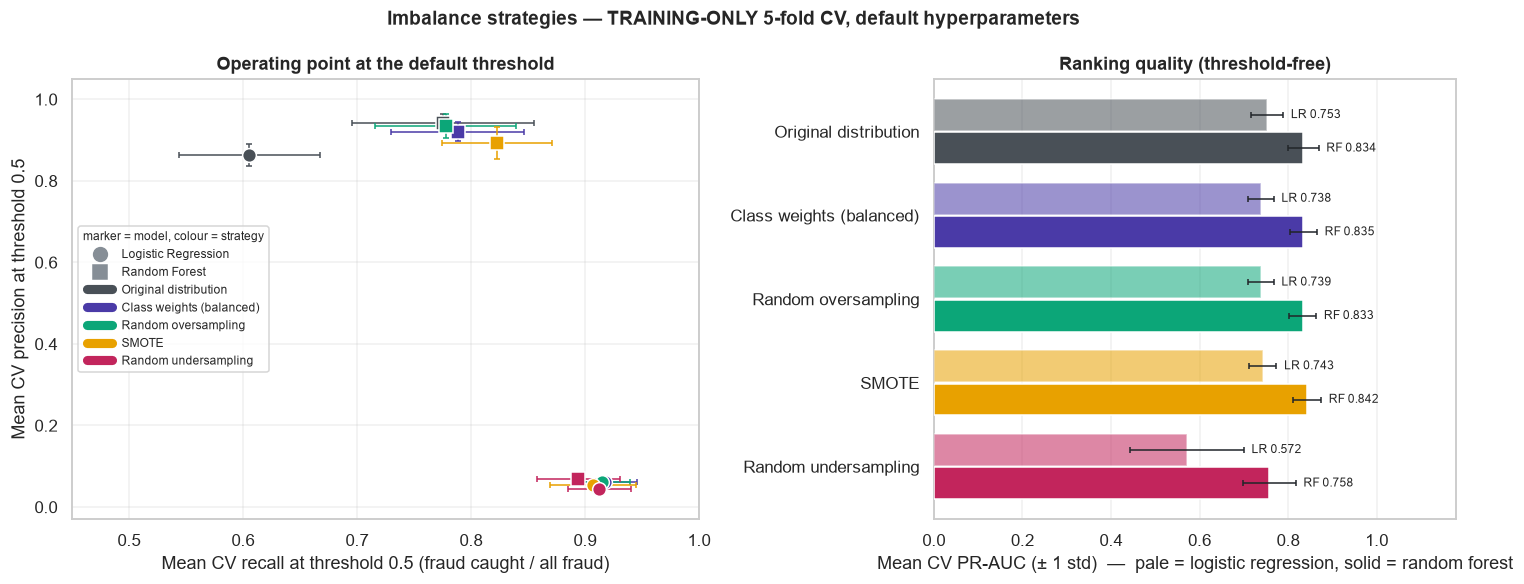

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), gridspec_kw={"width_ratios": [1.2, 1]})
ax = axes[0]
for model, names in (("logistic_regression", LR_IMB_NAMES), ("random_forest", RF_IMB_NAMES)):
    for strategy, name in names.items():
        s = cv_results[name].summary()
        st = STRATEGY_STYLE[strategy]
        ax.errorbar(s["recall_mean"], s["precision_mean"], xerr=s["recall_std"], yerr=s["precision_std"],
                    fmt=MODEL_MARKER[model], color=st["color"], markersize=9, markeredgecolor="white",
                    elinewidth=1, capsize=2, zorder=4)
ax.set_xlabel("Mean CV recall at threshold 0.5 (fraud caught / all fraud)")
ax.set_ylabel("Mean CV precision at threshold 0.5")
ax.set_xlim(0.45, 1.0)
ax.set_ylim(-0.03, 1.05)
ax.set_title("Operating point at the default threshold")
handles = [Line2D([], [], marker=MODEL_MARKER[m], color="#868e96", linestyle="none", markersize=9,
                  label=mt.MODEL_LABELS[m]) for m in mt.MODELS]
handles += [Line2D([], [], color=STRATEGY_STYLE[s]["color"], linewidth=6, label=mt.STRATEGY_LABELS[s])
            for s in mt.STRATEGIES]
ax.legend(handles=handles, fontsize=8, loc="center left", frameon=True,
          title="marker = model, colour = strategy", title_fontsize=8)

ax = axes[1]
y = np.arange(5)
for offset, (model, names) in zip((-0.2, 0.2), (("logistic_regression", LR_IMB_NAMES), ("random_forest", RF_IMB_NAMES))):
    means = [cv_results[names[s]].summary()["pr_auc_mean"] for s in mt.STRATEGIES]
    stds = [cv_results[names[s]].summary()["pr_auc_std"] for s in mt.STRATEGIES]
    ax.barh(y + offset, means, height=0.38, color=[STRATEGY_STYLE[s]["color"] for s in mt.STRATEGIES],
            alpha=1.0 if model == "random_forest" else 0.55, zorder=3, edgecolor="white")
    ax.errorbar(means, y + offset, xerr=stds, fmt="none", ecolor="#212529", capsize=2, linewidth=1, zorder=4)
    for yy, mm, sd in zip(y + offset, means, stds):
        ax.annotate(f"{'RF' if model == 'random_forest' else 'LR'} {mm:.3f}", xy=(mm + sd, yy), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=8)
ax.set_yticks(y, [mt.STRATEGY_LABELS[s] for s in mt.STRATEGIES])
ax.invert_yaxis()
ax.set_xlim(0, 1.18)
ax.set_xlabel("Mean CV PR-AUC (± 1 std)  —  pale = logistic regression, solid = random forest")
ax.set_title("Ranking quality (threshold-free)")
ax.grid(axis="y", visible=False)
fig.suptitle("Imbalance strategies — TRAINING-ONLY 5-fold CV, default hyperparameters",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "20_imbalance_strategy_comparison.png")
plt.show()

---
## 7. Logistic Regression Validation

Fold-level detail for the logistic-regression configurations at the selected scaling. TRAIN-fold
figures are computed on each fold's own (un-resampled) training rows.

In [17]:
rows = []
for strategy, name in LR_IMB_NAMES.items():
    r = cv_results[name]
    rows.append({"imbalance": mt.STRATEGY_LABELS[strategy],
                 **{f"fold {f} PR-AUC": r.fold_metrics.loc[f, "pr_auc"] for f in r.fold_metrics.index},
                 "mean": r.fold_metrics["pr_auc"].mean(), "std": r.fold_metrics["pr_auc"].std(ddof=1),
                 "TRAIN-fold PR-AUC": r.train_fold_metrics["pr_auc"].mean(),
                 "convergence warnings": sum(1 for w in r.warnings if w[1] == "ConvergenceWarning")})
print(f"Logistic regression, scaling = {SELECTED_SCALING}: validation-fold PR-AUC by fold")
pd.DataFrame(rows).set_index("imbalance")

Logistic regression, scaling = standard: validation-fold PR-AUC by fold


,fold 1 PR-AUC,fold 2 PR-AUC,fold 3 PR-AUC,fold 4 PR-AUC,fold 5 PR-AUC,mean,std,TRAIN-fold PR-AUC,convergence warnings
imbalance,,,,,,,,,
Original distribution,0.748725,0.742716,0.704092,0.763328,0.804683,0.752709,0.036378,0.766084,0
Class weights (balanced),0.746217,0.733545,0.689705,0.761889,0.759812,0.738234,0.029436,0.741660,0
Random oversampling,0.746465,0.734971,0.690602,0.761722,0.759869,0.738726,0.029007,0.741916,0
SMOTE,0.746101,0.731084,0.697498,0.766979,0.773945,0.743121,0.030637,0.745051,0
Random undersampling,0.672213,0.597852,0.608585,0.347138,0.631797,0.571517,0.128634,0.549218,0


**Fold-level behaviour.** Fold 3 is the hardest fold for every logistic-regression strategy except undersampling (e.g. **0.704092** for the original distribution, against a mean of **0.752709**); fold 4 or 5 is the easiest. Because every configuration shares the same folds, that is a property of the data in fold 3, not of any model — and it is why differences between configurations must be read against the fold-to-fold spread rather than as absolute numbers.

Undersampling is the unstable exception: its fold-4 PR-AUC is **0.347138**, half of its other folds. Training on 604–606 rows (302–303 of each class, depending on the fold) leaves the model at the mercy of which 302–303 legitimate rows were drawn.

TRAIN-fold and validation PR-AUC are within ~0.01 for every strategy except undersampling, and **no convergence warning** was raised in any of the 75 fits: the linear model does not overfit, and `max_iter=1000` was ample.

---
## 8. Random Forest Validation

### 8.1 Does scaling change the forest?

The original-distribution forest is cross-validated under `minimal` and `log_amount` scaling. Its
out-of-fold probabilities are compared **row by row** with the `standard` run from section 6 (exact
invariance), and its CV PR-AUC is compared under Rule 2 (material effect).

In [18]:
for scaling in ("minimal", "log_amount"):
    run_cv(f"RF | {scaling} | original", "random_forest", "original", scaling=scaling)

base = cv_results[RF_IMB_NAMES["original"]].oof_proba
invariance = {}
for scaling in ("minimal", "log_amount"):
    other = cv_results[f"RF | {scaling} | original"].oof_proba
    invariance[scaling] = {"identical OOF probabilities": bool(np.array_equal(base.to_numpy(), other.to_numpy())),
                           "max |difference|": float(np.max(np.abs(base.to_numpy() - other.to_numpy())))}
RF_SCALE_INVARIANT = all(v["identical OOF probabilities"] for v in invariance.values())
print("random forest, original distribution - OOF probabilities vs the `standard` run:")
pd.DataFrame(invariance).T

RF | minimal | original                              PR-AUC 0.8334 ± 0.0347 | recall 0.7725 | precision 0.9451 | fit  284.5s


RF | log_amount | original                           PR-AUC 0.8342 ± 0.0349 | recall 0.7751 | precision 0.9427 | fit  282.6s
random forest, original distribution - OOF probabilities vs the `standard` run:


,identical OOF probabilities,max |difference|
minimal,False,0.180000
log_amount,False,0.010000


In [19]:
# SMOTE is the one strategy where scaling can matter for the forest. It is tested only if SMOTE is
# the forest's strategy going into tuning - otherwise the result could not change any decision.
if RF_STRATEGY == "smote":
    for scaling in ("minimal", "log_amount"):
        run_cv(f"RF | {scaling} | SMOTE", "random_forest", "smote", scaling=scaling)
    rf_scaling_names = [RF_IMB_NAMES["smote"], "RF | minimal | SMOTE", "RF | log_amount | SMOTE"]
else:
    rf_scaling_names = [RF_IMB_NAMES["original"], "RF | minimal | original", "RF | log_amount | original"]

rf_scaling_table = summary_table(rf_scaling_names)
RF_SCALING_CHOICE, RF_SCALING_BEST, RF_SCALING_SE, _ = one_se_choice(rf_scaling_table)
RF_SCALING = config_meta[RF_SCALING_CHOICE]["scaling"]
spread = rf_scaling_table["pr_auc_mean"].max() - rf_scaling_table["pr_auc_mean"].min()

print("exactly identical OOF probabilities across scalings:", RF_SCALE_INVARIANT)
print(f"CV PR-AUC spread across the three scalings: {spread:.6f}   vs one standard error: {RF_SCALING_SE:.6f}")
print("scaling changes the forest materially (spread > 1 SE):", bool(spread > RF_SCALING_SE))
print()
print(rf_scaling_table[["pr_auc_mean", "pr_auc_std", "recall_mean", "precision_mean"]].to_string())
print()
print(f"Rule 2 choice: {RF_SCALING_CHOICE}  ->  random-forest scaling carried forward: {RF_SCALING}")

exactly identical OOF probabilities across scalings: False
CV PR-AUC spread across the three scalings: 0.000731   vs one standard error: 0.015614
scaling changes the forest materially (spread > 1 SE): False

                            pr_auc_mean  pr_auc_std  recall_mean  precision_mean
configuration                                                                   
RF | standard | original       0.834131    0.034962     0.775088        0.942724
RF | minimal | original        0.833427    0.034715     0.772456        0.945096
RF | log_amount | original     0.834158    0.034915     0.775088        0.942724

Rule 2 choice: RF | standard | original  ->  random-forest scaling carried forward: standard


### 8.2 Fold-level detail, default hyperparameters

In [20]:
rows = []
for strategy, name in RF_IMB_NAMES.items():
    r = cv_results[name]
    rows.append({"imbalance": mt.STRATEGY_LABELS[strategy],
                 **{f"fold {f} PR-AUC": r.fold_metrics.loc[f, "pr_auc"] for f in r.fold_metrics.index},
                 "mean": r.fold_metrics["pr_auc"].mean(), "std": r.fold_metrics["pr_auc"].std(ddof=1),
                 "TRAIN-fold PR-AUC": r.train_fold_metrics["pr_auc"].mean(),
                 "TRAIN-fold recall": r.train_fold_metrics["recall"].mean(),
                 "fit s (5 folds)": sum(r.fit_seconds)})
print("Random forest, default hyperparameters: validation-fold PR-AUC by fold")
pd.DataFrame(rows).set_index("imbalance")

Random forest, default hyperparameters: validation-fold PR-AUC by fold


,fold 1 PR-AUC,fold 2 PR-AUC,fold 3 PR-AUC,fold 4 PR-AUC,fold 5 PR-AUC,mean,std,TRAIN-fold PR-AUC,TRAIN-fold recall,fit s (5 folds)
imbalance,,,,,,,,,,
Original distribution,0.821806,0.854238,0.778091,0.862005,0.854517,0.834131,0.034962,1.000000,1.000000,285.119960
Class weights (balanced),0.834893,0.863648,0.789115,0.823994,0.861813,0.834693,0.030683,1.000000,1.000000,114.488597
Random oversampling,0.836974,0.861092,0.782106,0.834850,0.850655,0.833136,0.030456,1.000000,1.000000,281.221163
SMOTE,0.837080,0.866311,0.790942,0.871873,0.846264,0.842494,0.032139,1.000000,1.000000,586.075442
Random undersampling,0.772742,0.759250,0.658239,0.783830,0.815526,0.757917,0.059472,0.838665,1.000000,2.624219


**Scaling and the forest.** The out-of-fold probabilities are **not** exactly identical across scalings — they differ by up to **0.18** under `minimal` (which reorders the columns, so each tree's random feature draw changes) and **0.01** under `log_amount` (one vote in 100, from float32 rounding). The *performance* effect is negligible: CV PR-AUC **0.834131** (`standard`), **0.833427** (`minimal`), **0.834158** (`log_amount`) — a spread of **0.0007**, a small fraction of one standard error. Rule 2 keeps `standard`. The earlier plan to call the forest "invariant" is therefore corrected to what the data shows: *not bit-identical, but not materially different.* Because the forest carries no resampler into tuning (class weights, not SMOTE), no distance-based step exists for scaling to affect.

**Every default forest memorises its training folds.** TRAIN-fold PR-AUC is **1.000000** and TRAIN-fold recall **1.000000** for the original, class-weighted, oversampled and SMOTE forests, against validation PR-AUC of **0.833–0.842**. The undersampled forest's TRAIN-fold PR-AUC is lower (**0.838665**) only because it never saw most of those training rows. This is the Phase 3 overfitting finding, reproduced on training data alone, and it is what the hyperparameter search in section 9 targets.

**Cost.** Five-fold fit time, range over three executions: class weights **27–28 s**, original **70–72 s**, oversampling **76–80 s**, SMOTE **136–140 s**, undersampling **~1 s**. Class weighting was consistently the fastest of the full-data forests (as in Phase 3); the reason was not investigated.

---
## 9. Hyperparameter Tuning

Both searches use the same five folds, `scoring = average precision` computed from probabilities,
`refit=False` (nothing is refitted on the full training set in this phase), and
`error_score="raise"` so a failed fit cannot be silently scored as NaN. The PR-AUC scorer is wrapped in
a recorder that logs **every row it scores** — direct evidence for section 16 that the searches never
saw a test row.

### 9.1 Logistic regression

**API check for scikit-learn 1.9.1.** `penalty` is deprecated (since 1.8, removal in 1.10). The penalty
type is set with `l1_ratio` — `0.0` = L2, `1.0` = L1 — and strength with `C` (`C=np.inf` would be
unpenalised). Solver compatibility, checked on one training fold before this phase:

| Penalty | Solver | Behaviour on a 181,584-row training fold |
|---|---|---|
| L2 (`l1_ratio=0`) | `lbfgs` | converges in ~15 iterations, ~0.2 s |
| L1 (`l1_ratio=1`) | `liblinear` | converges in 28 iterations, ~2.6 s |
| L1 (`l1_ratio=1`) | `saga` | **did not converge** in 1,000 iterations (88 s, `ConvergenceWarning`) — excluded |

`liblinear` penalises the intercept along with the coefficients; with standardised features and
`C ≥ 0.01` this has little practical effect, but it is a real difference from `lbfgs` and is noted.

**Search space:** `C ∈ {0.001, 0.01, 0.1, 1, 10, 100}` × {L2/`lbfgs`, L1/`liblinear`} = 12
configurations per imbalance strategy, run for the **two best LR strategies from section 6** at the
selected scaling: 24 configurations, **120 fits**. Small enough for a full grid.

In [21]:
C_GRID = [0.001, 0.01, 0.1, 1, 10, 100]
LR_PARAM_GRID = [
    {"classifier__C": C_GRID, "classifier__l1_ratio": [0.0], "classifier__solver": ["lbfgs"]},
    {"classifier__C": C_GRID, "classifier__l1_ratio": [1.0], "classifier__solver": ["liblinear"]},
]
lr_recorder = mt.RowRecordingScorer(mt.SCORING["pr_auc"])
lr_scoring = {**mt.SCORING, "pr_auc": lr_recorder}

lr_search_frames, lr_search_warnings, lr_search_seconds = [], [], {}
for strategy in LR_TUNING_STRATEGIES:
    search = GridSearchCV(mt.build_pipeline("logistic_regression", strategy, scaling=SELECTED_SCALING),
                          LR_PARAM_GRID, scoring=lr_scoring, refit=False, cv=cv, n_jobs=1,
                          return_train_score=True, error_score="raise")
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        start = time.perf_counter()
        search.fit(X_train, y_train)
        lr_search_seconds[strategy] = time.perf_counter() - start
    lr_search_warnings += [(strategy, w.category.__name__, str(w.message)[:140]) for w in caught]
    frame = mt.search_results_frame(search)
    frame.insert(0, "imbalance", strategy)
    lr_search_frames.append(frame)
    print(f"{strategy:<13}: {len(frame)} configurations x {search.n_splits_} folds = {len(frame) * search.n_splits_} fits "
          f"in {lr_search_seconds[strategy]:.1f}s")

lr_search = (pd.concat(lr_search_frames).sort_values("mean_test_pr_auc", ascending=False, kind="stable")
             .reset_index(drop=True))
lr_search["penalty"] = np.where(lr_search["l1_ratio"].astype(float) == 1.0, "L1", "L2")
print(f"warnings captured during the LR searches: {len(lr_search_warnings)}")
for w in lr_search_warnings[:8]:
    print("  ", w)

original     : 12 configurations x 5 folds = 60 fits in 220.0s


smote        : 12 configurations x 5 folds = 60 fits in 375.8s
warnings captured during the LR searches: 0


In [22]:
show = ["imbalance", "penalty", "C", "solver", "mean_test_pr_auc", "std_test_pr_auc", "mean_test_recall",
        "mean_test_precision", "mean_test_f1", "mean_train_pr_auc"]
print("LOGISTIC REGRESSION SEARCH - top 10 of", len(lr_search), "by mean CV PR-AUC (TRAINING-ONLY CV)")
lr_search[show].head(10)

LOGISTIC REGRESSION SEARCH - top 10 of 24 by mean CV PR-AUC (TRAINING-ONLY CV)


,imbalance,penalty,C,solver,mean_test_pr_auc,std_test_pr_auc,mean_test_recall,mean_test_precision,mean_test_f1,mean_train_pr_auc
0,original,L1,0.100000,liblinear,0.755871,0.029054,0.584526,0.874277,0.699308,0.765012
1,original,L1,1.000000,liblinear,0.754635,0.031886,0.613649,0.861900,0.714792,0.767787
2,original,L1,10.000000,liblinear,0.754037,0.032266,0.616281,0.862241,0.717202,0.767758
3,original,L1,100.000000,liblinear,0.753857,0.032319,0.616281,0.862241,0.717202,0.767728
4,original,L2,0.010000,lbfgs,0.753707,0.026294,0.579228,0.877432,0.696001,0.760282
5,original,L2,0.100000,lbfgs,0.753157,0.031721,0.595053,0.863959,0.702430,0.765856
6,original,L2,1.000000,lbfgs,0.752709,0.032537,0.605649,0.863288,0.709644,0.766084
7,original,L2,100.000000,lbfgs,0.752125,0.032886,0.605649,0.863288,0.709644,0.766002
8,original,L2,10.000000,lbfgs,0.752121,0.032972,0.605649,0.863288,0.709644,0.766009
9,original,L2,0.001000,lbfgs,0.751169,0.026614,0.489193,0.862661,0.622328,0.755071


In [23]:
top_lr = lr_search.iloc[0]
LR_BEST_PARAMS = {"C": float(top_lr["C"]), "l1_ratio": float(top_lr["l1_ratio"]), "solver": str(top_lr["solver"])}
LR_BEST_STRATEGY = str(top_lr["imbalance"])
LR_FINALIST = f"LR tuned | {SELECTED_SCALING} | {SHORT[LR_BEST_STRATEGY]} | C={LR_BEST_PARAMS['C']:g} {top_lr['penalty']}"
print("best logistic regression by mean CV PR-AUC:")
print("  imbalance :", LR_BEST_STRATEGY)
print("  params    :", LR_BEST_PARAMS)
print(f"  CV PR-AUC : {top_lr['mean_test_pr_auc']:.6f} ± {top_lr['std_test_pr_auc']:.6f}")

best logistic regression by mean CV PR-AUC:
  imbalance : original
  params    : {'C': 0.1, 'l1_ratio': 1.0, 'solver': 'liblinear'}
  CV PR-AUC : 0.755871 ± 0.029054


### 9.2 Random forest

Phase 3 showed the default forest memorising its training data (TRAIN recall ≥ 0.997 vs TEST
0.73–0.77), so the search concentrates on the parameters that regularise a forest, plus class
weighting:

| Parameter | Values | Why |
|---|---|---|
| `min_samples_leaf` | 1, 5, 20 | the main brake on memorisation — 1 is the overfitted default |
| `max_features` | `"sqrt"` (≈5 of 30), 0.3 (9 of 30) | decorrelated weak trees vs fewer, stronger trees |
| `class_weight` | None, `"balanced"` | reweighting instead of, or on top of, the carried strategy |
| `max_depth` | fixed at None | leaf size already regularises depth; a depth cap mostly duplicates it |
| `n_estimators` | fixed at 100 in the search | more trees reduce variance but do not change what is learned; checked separately in 9.3 |

**A full `GridSearchCV`: 3 × 2 × 2 = 12 configurations, 60 fits.** Deterministic and small enough to
report in full.

**Why the search is this size — a documented revision.** The first execution of this notebook used a
`RandomizedSearchCV` over a 72-configuration space (`min_samples_leaf` 1/3/10/30, `max_depth`
None/12/24, `max_features` sqrt/0.3, `class_weight` None/balanced/balanced_subsample; `n_iter=16`, 80
fits). It had to be stopped after about two hours with only ~7 of its 80 fits complete. A stack sample
(`py-spy`) showed it inside the forest fit of candidate 2 of 16, with the kernel using a single core. The
same fits measured afterwards in a fresh kernel ran at full speed on ~11 cores (13.9 s default, 24.6 s with
`max_features=0.3`, 28.7 s after SMOTE, per training fold), so the slowdown came from machine state during
that run. Later executions showed the same pattern intermittently: total CPU load of ~85% while the kernel
used ~31% of it, the remainder taken by processes not visible to this user account. The exact source was not
established; it affects runtime only, never results. No result from that run was used: it was stopped before
the search produced any score, and nothing it computed survives. The grid above replaces it so that the
search's cost stays bounded even if the machine slows down again. The imbalance strategy is the one
section 6 carried forward for the forest.

In [24]:
RF_PARAM_GRID = {
    "classifier__min_samples_leaf": [1, 5, 20],
    "classifier__max_features": ["sqrt", 0.3],
    "classifier__class_weight": [None, "balanced"],
}
n_space = int(np.prod([len(v) for v in RF_PARAM_GRID.values()]))
print(f"full grid: {n_space} configurations x {mt.N_SPLITS} folds = {n_space * mt.N_SPLITS} fits")
print(f"imbalance strategy: {RF_STRATEGY} | scaling: {RF_SCALING}")

rf_recorder = mt.RowRecordingScorer(mt.SCORING["pr_auc"])
rf_scoring = {**mt.SCORING, "pr_auc": rf_recorder}
rf_search_obj = GridSearchCV(mt.build_pipeline("random_forest", RF_STRATEGY, scaling=RF_SCALING),
                             RF_PARAM_GRID, scoring=rf_scoring, refit=False, cv=cv, n_jobs=1,
                             return_train_score=True, error_score="raise")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    start = time.perf_counter()
    rf_search_obj.fit(X_train, y_train)
    RF_SEARCH_SECONDS = time.perf_counter() - start
rf_search_warnings = [(w.category.__name__, str(w.message)[:140]) for w in caught]
rf_search = mt.search_results_frame(rf_search_obj)
print(f"completed in {RF_SEARCH_SECONDS / 60:.1f} min ({RF_SEARCH_SECONDS / (n_space * mt.N_SPLITS):.1f} s per fit incl. "
      f"scoring); warnings captured: {len(rf_search_warnings)}")

full grid: 12 configurations x 5 folds = 60 fits
imbalance strategy: class_weight | scaling: standard


completed in 59.0 min (59.0 s per fit incl. scoring); warnings captured: 0


In [25]:
show = ["min_samples_leaf", "max_features", "class_weight", "mean_test_pr_auc", "std_test_pr_auc",
        "mean_test_recall", "mean_test_precision", "mean_test_f1", "mean_train_pr_auc", "mean_train_recall"]
print("RANDOM FOREST GRID - all", len(rf_search), "configurations by mean CV PR-AUC (TRAINING-ONLY CV)")
rf_search[show]

RANDOM FOREST GRID - all 12 configurations by mean CV PR-AUC (TRAINING-ONLY CV)


,min_samples_leaf,max_features,class_weight,mean_test_pr_auc,std_test_pr_auc,mean_test_recall,mean_test_precision,mean_test_f1,mean_train_pr_auc,mean_train_recall
0,5,0.300000,NaN,0.838580,0.040076,0.777719,0.926667,0.843867,0.972575,0.828698
1,5,sqrt,balanced,0.836467,0.034384,0.822772,0.839768,0.830186,0.999136,1.000000
2,1,0.300000,NaN,0.835568,0.030450,0.790982,0.941243,0.857785,1.000000,1.000000
3,1,sqrt,balanced,0.834693,0.027444,0.788246,0.921052,0.848139,1.000000,1.000000
4,1,sqrt,NaN,0.834131,0.031271,0.775088,0.942724,0.848777,1.000000,1.000000
5,5,0.300000,balanced,0.833024,0.033478,0.825404,0.830195,0.826640,0.997331,1.000000
6,5,sqrt,NaN,0.831938,0.039265,0.753965,0.928135,0.830066,0.971105,0.822082
7,1,0.300000,balanced,0.824187,0.026341,0.798947,0.921674,0.854653,1.000000,1.000000
8,20,0.300000,NaN,0.821889,0.039566,0.740702,0.887618,0.804900,0.913219,0.767864
9,20,0.300000,balanced,0.818204,0.031958,0.835965,0.672174,0.743576,0.968467,1.000000


In [26]:
top_rf = rf_search.iloc[0]
RF_BEST_PARAMS = {
    "min_samples_leaf": int(top_rf["min_samples_leaf"]),
    "max_depth": None,                                   # fixed, not searched
    "max_features": top_rf["max_features"] if isinstance(top_rf["max_features"], str) else float(top_rf["max_features"]),
    "class_weight": None if pd.isna(top_rf["class_weight"]) else str(top_rf["class_weight"]),
}
# If the forest carries no resampler, whether it is "class weights" or "original" is decided by the
# class_weight the search actually chose - not by the label it entered the search with.
if RF_STRATEGY in ("original", "class_weight"):
    RF_TUNED_STRATEGY = "class_weight" if RF_BEST_PARAMS["class_weight"] else "original"
else:
    RF_TUNED_STRATEGY = RF_STRATEGY
print("best random forest by mean CV PR-AUC (100 trees):", RF_BEST_PARAMS)
print("effective imbalance strategy of the tuned forest:", RF_TUNED_STRATEGY)
print(f"CV PR-AUC {top_rf['mean_test_pr_auc']:.6f} ± {top_rf['std_test_pr_auc']:.6f}")

best random forest by mean CV PR-AUC (100 trees): {'min_samples_leaf': 5, 'max_depth': None, 'max_features': 0.3, 'class_weight': None}
effective imbalance strategy of the tuned forest: original
CV PR-AUC 0.838580 ± 0.040076


### 9.3 Out-of-fold re-runs and the ensemble-size check

The two search winners are cross-validated again with the section 4 helper, which produces the
out-of-fold probabilities, TRAIN-fold metrics and per-fold bookkeeping the searches do not keep. Because
the folds, pipelines and seeds are identical, the re-run must reproduce the search's per-fold PR-AUC
exactly — that is checked, not assumed.

The forest winner is also run with **300 trees**. By the declared simplicity order, 300 trees are only
adopted if they beat 100 by more than one standard error.

In [27]:
run_cv(LR_FINALIST, "logistic_regression", LR_BEST_STRATEGY, scaling=SELECTED_SCALING, classifier_params=LR_BEST_PARAMS)
rf100 = f"RF tuned | {RF_SCALING} | {SHORT[RF_TUNED_STRATEGY]} | 100 trees"
rf300 = f"RF tuned | {RF_SCALING} | {SHORT[RF_TUNED_STRATEGY]} | 300 trees"
run_cv(rf100, "random_forest", RF_TUNED_STRATEGY, scaling=RF_SCALING, classifier_params={**RF_BEST_PARAMS, "n_estimators": 100})
run_cv(rf300, "random_forest", RF_TUNED_STRATEGY, scaling=RF_SCALING, classifier_params={**RF_BEST_PARAMS, "n_estimators": 300})

lr_split_scores = lr_search.iloc[0][[f"split{i}_test_pr_auc" for i in range(5)]].to_numpy(dtype=float)
rf_split_scores = rf_search.iloc[0][[f"split{i}_test_pr_auc" for i in range(5)]].to_numpy(dtype=float)
SEARCH_RERUN_CONSISTENT = (np.allclose(cv_results[LR_FINALIST].fold_metrics["pr_auc"].to_numpy(), lr_split_scores, rtol=0, atol=1e-12)
                           and np.allclose(cv_results[rf100].fold_metrics["pr_auc"].to_numpy(), rf_split_scores, rtol=0, atol=1e-12))
print()
print("OOF re-runs reproduce the search's per-fold PR-AUC exactly:", SEARCH_RERUN_CONSISTENT)

trees = summary_table([rf100, rf300])
tree_choice, _, tree_se, _ = one_se_choice(trees)
RF_FINALIST = tree_choice
print(f"100 vs 300 trees: {trees.loc[rf100, 'pr_auc_mean']:.6f} vs {trees.loc[rf300, 'pr_auc_mean']:.6f} "
      f"(1 SE = {tree_se:.6f}) -> Rule 2 keeps: {RF_FINALIST}")

LR tuned | standard | original | C=0.1 L1            PR-AUC 0.7559 ± 0.0325 | recall 0.5845 | precision 0.8743 | fit   14.3s


RF tuned | standard | original | 100 trees           PR-AUC 0.8386 ± 0.0448 | recall 0.7777 | precision 0.9267 | fit  507.4s


RF tuned | standard | original | 300 trees           PR-AUC 0.8403 ± 0.0428 | recall 0.7830 | precision 0.9275 | fit 1255.4s

OOF re-runs reproduce the search's per-fold PR-AUC exactly: True
100 vs 300 trees: 0.838580 vs 0.840258 (1 SE = 0.019159) -> Rule 2 keeps: RF tuned | standard | original | 100 trees


In [28]:
baseline_lr_name = LR_IMB_NAMES["original"]
hp_rows = [
    ("Logistic regression", "scaling", "standard", SELECTED_SCALING, "section 5, Rule 2"),
    ("Logistic regression", "imbalance", "original / class weights (Phase 3 set)", SHORT[LR_BEST_STRATEGY], "section 6 top-2, then search"),
    ("Logistic regression", "C", "1.0", f"{LR_BEST_PARAMS['C']:g}", "highest mean CV PR-AUC in 9.1"),
    ("Logistic regression", "penalty (l1_ratio)", "L2 (0.0)", f"{'L1' if LR_BEST_PARAMS['l1_ratio'] == 1 else 'L2'} ({LR_BEST_PARAMS['l1_ratio']})", "highest mean CV PR-AUC in 9.1"),
    ("Logistic regression", "solver", "lbfgs", LR_BEST_PARAMS["solver"], "follows the penalty"),
    ("Random forest", "scaling", "standard", RF_SCALING, "section 8 (invariance / SMOTE check)"),
    ("Random forest", "imbalance", "all five (Phase 3 set)", SHORT[RF_TUNED_STRATEGY], "section 6, Rule 2 (+ search class_weight)"),
    ("Random forest", "min_samples_leaf", "1", str(RF_BEST_PARAMS["min_samples_leaf"]), "highest mean CV PR-AUC in 9.2"),
    ("Random forest", "max_depth", "None", "None", "not searched - min_samples_leaf regularises"),
    ("Random forest", "max_features", "sqrt", str(RF_BEST_PARAMS["max_features"]), "highest mean CV PR-AUC in 9.2"),
    ("Random forest", "class_weight", "None / balanced (by strategy)", str(RF_BEST_PARAMS["class_weight"]), "highest mean CV PR-AUC in 9.2"),
    ("Random forest", "n_estimators", "100", str(config_meta[RF_FINALIST]["n_estimators"]), "section 9.3, Rule 2"),
]
hp_table = pd.DataFrame(hp_rows, columns=["model", "parameter", "baseline", "selected", "reason"])
hp_table

,model,parameter,baseline,selected,reason
0,Logistic regression,scaling,standard,standard,"section 5, Rule 2"
1,Logistic regression,imbalance,original / class weights (Phase 3 set),original,"section 6 top-2, then search"
2,Logistic regression,C,1.0,0.1,highest mean CV PR-AUC in 9.1
3,Logistic regression,penalty (l1_ratio),L2 (0.0),L1 (1.0),highest mean CV PR-AUC in 9.1
4,Logistic regression,solver,lbfgs,liblinear,follows the penalty
5,Random forest,scaling,standard,standard,section 8 (invariance / SMOTE check)
6,Random forest,imbalance,all five (Phase 3 set),original,"section 6, Rule 2 (+ search class_weight)"
7,Random forest,min_samples_leaf,1,5,highest mean CV PR-AUC in 9.2
8,Random forest,max_depth,None,None,not searched - min_samples_leaf regularises
9,Random forest,max_features,sqrt,0.3,highest mean CV PR-AUC in 9.2


**Logistic regression — tuning changes almost nothing.** The best configuration is the original distribution with an **L1 penalty (`liblinear`), C = 0.1: mean CV PR-AUC 0.755871**, against **0.752709** for the untuned default (L2, C = 1). The gain, **+0.0032**, is about a fifth of a standard error. The top nine configurations all sit between **0.7521 and 0.7559**; only the extreme C = 0.001 with L1 visibly degrades (**0.692**, it zeroes most coefficients). The SMOTE variants never exceed **~0.743**. Selected: `C=0.1`, `l1_ratio=1.0`, `solver="liblinear"` — reported as selected, but the honest reading is that logistic regression is flat across this whole grid.

**Random forest — regularisation removes most of the memorisation at no cost in PR-AUC.** Best: **`min_samples_leaf=5`, `max_features=0.3`, `class_weight=None`: mean CV PR-AUC 0.838580**, against **0.834131** for the default forest — again inside one standard error. The more useful change is in *how* it gets there: TRAIN-fold PR-AUC falls from **1.000000** to **0.972575** and TRAIN-fold recall from **1.000000** to **0.828698** (section 13). `min_samples_leaf=20` over-regularises (**0.811–0.822**). `class_weight="balanced"` with leaf 20 shifts the operating point toward recall (**0.849**) at a large precision cost (**0.707**) — another operating-point effect, not a ranking gain.

**300 trees vs 100.** 300 trees score **0.840258** against **0.838580** — a difference of **0.0017**, below one standard error (**0.019159**) — at roughly three times the fit cost (**~357–363 s** vs **~121–123 s** for five folds). Rule 2 keeps **100 trees**.

**Search cost.** Logistic regression: 2 × 12 configurations = **120 fits** in **92–103 s** (original) and **150–175 s** (SMOTE). Random forest: 12 configurations = **60 fits** in **15–16 min** (range over three executions). Both OOF re-runs reproduced the search's per-fold PR-AUC exactly.

**A note on the two standard deviations.** The search tables report scikit-learn's `std_test_pr_auc`, a population standard deviation (`ddof=0`; **0.040076** for the forest winner). Every other table in this notebook — and Rule 2 — uses the sample standard deviation (`ddof=1`; **0.044807** for the same five fold scores). The folds are identical; only the divisor differs.

### Visualisation 21 — hyperparameter comparison

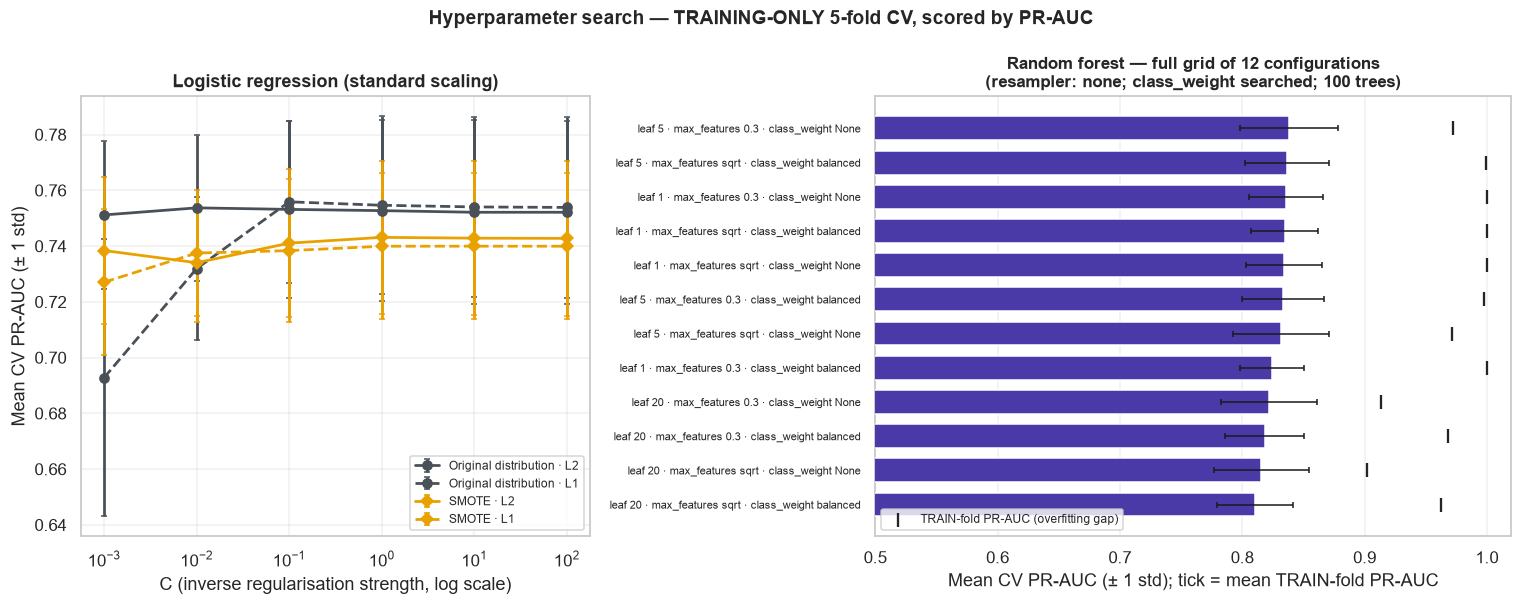

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1, 1.25]})
ax = axes[0]
for strategy in LR_TUNING_STRATEGIES:
    for penalty, ls in (("L2", "-"), ("L1", "--")):
        sub = lr_search[(lr_search["imbalance"] == strategy) & (lr_search["penalty"] == penalty)].copy()
        sub["C"] = sub["C"].astype(float)
        sub = sub.sort_values("C")
        ax.errorbar(sub["C"], sub["mean_test_pr_auc"], yerr=sub["std_test_pr_auc"], color=STRATEGY_STYLE[strategy]["color"],
                    ls=ls, marker=STRATEGY_STYLE[strategy]["marker"], markersize=6, capsize=2, linewidth=1.8,
                    label=f"{mt.STRATEGY_LABELS[strategy]} · {penalty}")
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularisation strength, log scale)")
ax.set_ylabel("Mean CV PR-AUC (± 1 std)")
ax.set_title(f"Logistic regression ({SELECTED_SCALING} scaling)")
ax.legend(fontsize=8, frameon=True, loc="lower right")

ax = axes[1]
ranked = rf_search.iloc[::-1].reset_index(drop=True)
labels = [f"leaf {int(r.min_samples_leaf)} · max_features {r.max_features} · "
          f"class_weight {r.class_weight if isinstance(r.class_weight, str) else 'None'}"
          for r in ranked.itertuples()]
ax.barh(range(len(ranked)), ranked["mean_test_pr_auc"], xerr=ranked["std_test_pr_auc"],
        color=STRATEGY_STYLE[RF_STRATEGY]["color"], height=0.7, zorder=3, capsize=2, error_kw={"linewidth": 1})
ax.scatter(ranked["mean_train_pr_auc"], range(len(ranked)), marker="|", s=90, color="#212529", zorder=4,
           label="TRAIN-fold PR-AUC (overfitting gap)")
ax.set_yticks(range(len(ranked)), labels, fontsize=7.5)
ax.set_xlim(min(0.5, float((ranked["mean_test_pr_auc"] - ranked["std_test_pr_auc"]).min()) - 0.03), 1.02)
ax.set_xlabel("Mean CV PR-AUC (± 1 std); tick = mean TRAIN-fold PR-AUC")
ax.set_title(f"Random forest — full grid of {len(rf_search)} configurations\n"
             f"(resampler: {'none' if RF_STRATEGY in ('original', 'class_weight') else SHORT[RF_STRATEGY]}; "
             f"class_weight searched; 100 trees)", fontsize=11)
ax.legend(fontsize=8, loc="lower left", frameon=True)
ax.grid(axis="y", visible=False)
fig.suptitle("Hyperparameter search — TRAINING-ONLY 5-fold CV, scored by PR-AUC", fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "21_hyperparameter_comparison.png")
plt.show()

---
## 10. Precision-Recall Trade-off (out-of-fold)

From here on the analysis concentrates on the two **finalists** — the tuned logistic regression and the
tuned random forest. Their precision-recall curves are built from **out-of-fold** probabilities: every
one of the 226,980 training rows is scored exactly once, by the one model that did not train on it.

In [30]:
FINALISTS = {"logistic_regression": LR_FINALIST, "random_forest": RF_FINALIST}
for model, name in FINALISTS.items():
    oof = cv_results[name].oof_proba
    print(f"{name}")
    print(f"  OOF length {len(oof):,} (= training rows {len(X_train):,}) | NaN {int(oof.isna().sum())} | "
          f"index aligned {oof.index.equals(X_train.index)} | range [{oof.min():.4f}, {oof.max():.4f}]")

LR tuned | standard | original | C=0.1 L1
  OOF length 226,980 (= training rows 226,980) | NaN 0 | index aligned True | range [0.0000, 1.0000]
RF tuned | standard | original | 100 trees
  OOF length 226,980 (= training rows 226,980) | NaN 0 | index aligned True | range [0.0000, 1.0000]


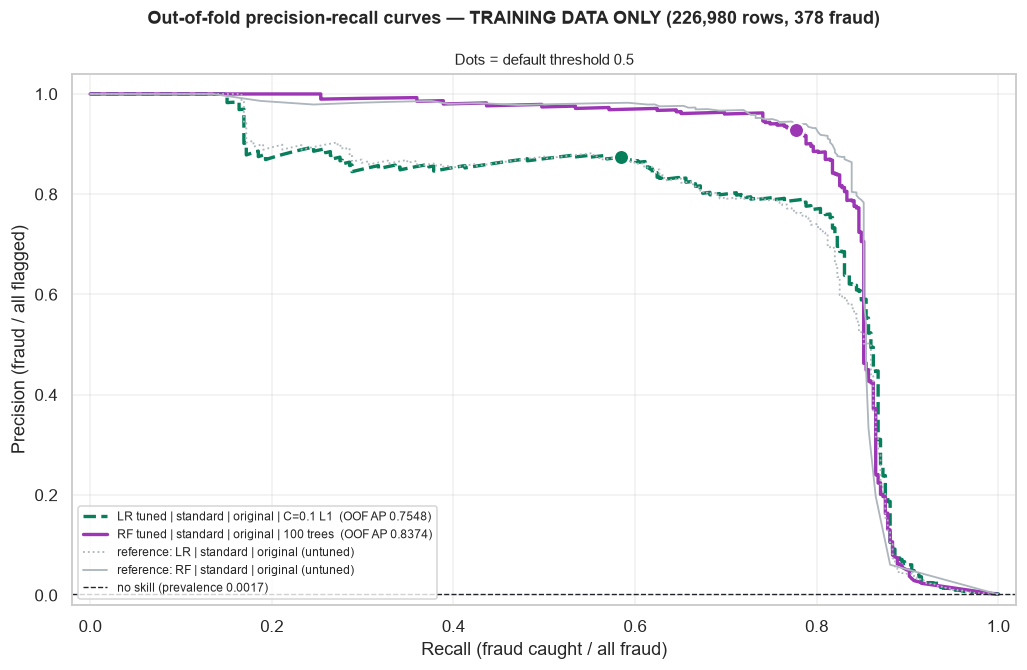

In [31]:
fig, ax = plt.subplots(figsize=(9.5, 6.2))
for model, name in FINALISTS.items():
    oof = cv_results[name].oof_proba
    prec, rec, _ = precision_recall_curve(y_train, oof, pos_label=1)
    ap = mt.average_precision_score(y_train, oof)
    ax.plot(rec, prec, color=FINALIST_COLOR[model], linewidth=2.2, ls="-" if model == "random_forest" else "--",
            label=f"{name}  (OOF AP {ap:.4f})")
    at_half = mt.threshold_table(y_train, oof, [0.5]).iloc[0]
    ax.plot(at_half["recall"], at_half["precision"], marker="o", markersize=10, color=FINALIST_COLOR[model],
            markeredgecolor="white", markeredgewidth=1.5, linestyle="none", zorder=5)
for model in ("logistic_regression", "random_forest"):
    ref = LR_IMB_NAMES["original"] if model == "logistic_regression" else RF_IMB_NAMES["original"]
    prec, rec, _ = precision_recall_curve(y_train, cv_results[ref].oof_proba, pos_label=1)
    ax.plot(rec, prec, color="#adb5bd", linewidth=1.2, ls=":" if model == "logistic_regression" else "-",
            label=f"reference: {ref} (untuned)")
prevalence = float(y_train.mean())
ax.axhline(prevalence, color="#212529", ls="--", linewidth=0.9, label=f"no skill (prevalence {prevalence:.4f})")
ax.set_xlabel("Recall (fraud caught / all fraud)")
ax.set_ylabel("Precision (fraud / all flagged)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.04)
ax.legend(fontsize=8, loc="lower left", frameon=True)
ax.set_title("Dots = default threshold 0.5", fontsize=9.5, fontweight="normal")
fig.suptitle("Out-of-fold precision-recall curves — TRAINING DATA ONLY (226,980 rows, 378 fraud)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "23_oof_precision_recall_curve.png")
plt.show()

**Reading the curves.** Pooled out-of-fold average precision is **0.8374** for the tuned forest and **0.7548** for the tuned logistic regression. (These pooled values differ slightly from the fold means, 0.838580 and 0.755871, because pooling ranks all 226,980 rows together instead of averaging five per-fold rankings.)

* The forest's curve sits above the logistic regression's for almost the whole recall range: it holds precision above **0.9** until recall ≈ **0.78**, where the logistic regression is already down to about **0.79**.
* **Both curves fall off a cliff at recall ≈ 0.85.** Beyond that point every additional fraud caught costs a steep rise in false alarms, for either family. This is the same boundary Phase 3 found on the holdout, where 11 frauds were missed by every configuration: a subset of frauds sits inside legitimate traffic on every feature the models use.
* Tuned and untuned curves nearly overlap for both families — consistent with tuning moving PR-AUC by less than a standard error.

**The trade-off, stated plainly.** Moving the threshold down catches more fraud and flags more legitimate transactions; moving it up does the reverse. Which point is right depends on the relative cost of a missed fraud and a blocked customer — a cost this dataset does not contain. That is why section 11 applies a declared rule rather than choosing a point by eye.

---
## 11. Threshold Analysis (out-of-fold)

Rule 3 is applied to each finalist's out-of-fold probabilities. Every number in this section comes
from training rows scored out-of-fold; no test probability exists in this notebook.

In [32]:
threshold_results = {}
for model, name in FINALISTS.items():
    chosen, table, edge = choose_threshold(y_train.to_numpy(), cv_results[name].oof_proba.to_numpy())
    threshold_results[model] = {"threshold": chosen, "table": table, "edge": edge}
    row = table.loc[chosen]
    print(f"{name}")
    print(f"  max-F1 threshold (Rule 3): {chosen:.2f}" + (f"   [grid extended at the {edge} edge]" if edge else ""))
    print(f"  OOF precision {row['precision']:.6f} | recall {row['recall']:.6f} | F1 {row['f1']:.6f} | "
          f"FP {int(row['fp']):,} | FN {int(row['fn'])} | TP {int(row['tp'])}")
    half = table.loc[0.5] if 0.5 in table.index else None
    if half is not None:
        print(f"  at 0.50  : precision {half['precision']:.6f} | recall {half['recall']:.6f} | F1 {half['f1']:.6f} | "
              f"FP {int(half['fp']):,} | FN {int(half['fn'])}")
    print()

LR tuned | standard | original | C=0.1 L1
  max-F1 threshold (Rule 3): 0.10
  OOF precision 0.788204 | recall 0.777778 | F1 0.782956 | FP 79 | FN 84 | TP 294
  at 0.50  : precision 0.873518 | recall 0.584656 | F1 0.700475 | FP 32 | FN 157

RF tuned | standard | original | 100 trees
  max-F1 threshold (Rule 3): 0.50
  OOF precision 0.927445 | recall 0.777778 | F1 0.846043 | FP 23 | FN 84 | TP 294
  at 0.50  : precision 0.927445 | recall 0.777778 | F1 0.846043 | FP 23 | FN 84



Full out-of-fold threshold table for each finalist (the requested 0.05–0.95 grid, plus any
declared edge extension):

In [33]:
print(FINALISTS["random_forest"])
threshold_results["random_forest"]["table"][["precision", "recall", "f1", "tp", "fp", "fn", "flagged"]]

RF tuned | standard | original | 100 trees


,precision,recall,f1,tp,fp,fn,flagged
threshold,,,,,,,
0.050000,0.568905,0.851852,0.682203,322,244,56,566
0.100000,0.707048,0.849206,0.771635,321,133,57,454
0.150000,0.758294,0.846561,0.800000,320,102,58,422
0.200000,0.787500,0.833333,0.809769,315,85,63,400
0.250000,0.825397,0.825397,0.825397,312,66,66,378
0.300000,0.844262,0.817460,0.830645,309,57,69,366
0.350000,0.869688,0.812169,0.839945,307,46,71,353
0.400000,0.887906,0.796296,0.839609,301,38,77,339
0.450000,0.911315,0.788360,0.845390,298,29,80,327


In [34]:
print(FINALISTS["logistic_regression"])
threshold_results["logistic_regression"]["table"][["precision", "recall", "f1", "tp", "fp", "fn", "flagged"]]

LR tuned | standard | original | C=0.1 L1


,precision,recall,f1,tp,fp,fn,flagged
threshold,,,,,,,
0.050000,0.744578,0.817460,0.779319,309,106,69,415
0.100000,0.788204,0.777778,0.782956,294,79,84,373
0.150000,0.791667,0.753968,0.772358,285,75,93,360
0.200000,0.794203,0.724868,0.757953,274,71,104,345
0.250000,0.800604,0.701058,0.747532,265,66,113,331
0.300000,0.803797,0.671958,0.731988,254,62,124,316
0.350000,0.832215,0.656085,0.733728,248,50,130,298
0.400000,0.850909,0.619048,0.716692,234,41,144,275
0.450000,0.866920,0.603175,0.711388,228,35,150,263


### 11.1 How stable is the chosen threshold?

Rule 3 is re-applied **within each validation fold separately**. If the per-fold optima scatter widely,
the pooled choice is fragile; if they cluster, it is not an artefact of one fold.

In [35]:
per_fold_rows = []
for model, name in FINALISTS.items():
    r = cv_results[name]
    for fold in range(1, mt.N_SPLITS + 1):
        mask = (r.fold_of_row == fold).to_numpy()
        t, tab, _ = choose_threshold(y_train.to_numpy()[mask], r.oof_proba.to_numpy()[mask])
        per_fold_rows.append({"finalist": mt.MODEL_LABELS[model], "fold": fold, "max-F1 threshold": t,
                              "F1 there": tab.loc[t, "f1"],
                              "F1 at pooled threshold": tab.loc[threshold_results[model]["threshold"], "f1"]
                              if threshold_results[model]["threshold"] in tab.index else np.nan})
per_fold_thresholds = pd.DataFrame(per_fold_rows).set_index(["finalist", "fold"])
per_fold_thresholds

max-F1 threshold  F1 there  F1 at pooled threshold
finalist            fold                                                    
Logistic Regression 1             0.050000  0.789809                0.751678
                    2             0.100000  0.786667                0.786667
                    3             0.100000  0.739130                0.739130
                    4             0.150000  0.800000                0.795031
                    5             0.100000  0.836601                0.836601
Random Forest       1             0.200000  0.835616                0.820896
                    2             0.400000  0.887324                0.869565
                    3             0.250000  0.758621                0.748092
                    4             0.450000  0.893333                0.891892
                    5             0.500000  0.888889                0.888889

### 11.2 Alternative operating rules — shown for transparency, not selected

Two common alternatives, computed on the same out-of-fold probabilities. They illustrate what a
different business priority would cost; they are **not** used, because Rule 3 was declared first.

In [36]:
alt_rows = []
for model, name in FINALISTS.items():
    tab = threshold_results[model]["table"]
    for label, mask in (("highest threshold with recall >= 0.85", tab["recall"] >= 0.85),
                        ("lowest threshold with precision >= 0.90", tab["precision"] >= 0.90)):
        cands = tab[mask]
        if len(cands) == 0:
            alt_rows.append({"finalist": mt.MODEL_LABELS[model], "rule": label, "threshold": np.nan})
            continue
        t = cands.index.max() if "recall" in label else cands.index.min()
        r = tab.loc[t]
        alt_rows.append({"finalist": mt.MODEL_LABELS[model], "rule": label, "threshold": t,
                         "precision": r["precision"], "recall": r["recall"], "f1": r["f1"],
                         "fp": int(r["fp"]), "fn": int(r["fn"])})
pd.DataFrame(alt_rows).set_index(["finalist", "rule"])

threshold  precision   recall       f1         fp        fn
finalist            rule                                                                                                
Logistic Regression highest threshold with recall >= 0.85          NaN        NaN      NaN      NaN        NaN       NaN
                    lowest threshold with precision >= 0.90        NaN        NaN      NaN      NaN        NaN       NaN
Random Forest       highest threshold with recall >= 0.85     0.050000   0.568905 0.851852 0.682203 244.000000 56.000000
                    lowest threshold with precision >= 0.90   0.450000   0.911315 0.788360 0.845390  29.000000 80.000000

**The forest (candidate).** Rule 3 selects **0.50** — the maximum out-of-fold F1 (**0.846043**: precision **0.927445**, recall **0.777778**, **23** false positives, **84** false negatives). The tie-break was not needed. Two honest qualifications:

* **The F1 curve is flat around the maximum.** Between 0.35 and 0.50 F1 ranges only **0.839945–0.846043**, while false positives range **46 → 23** and false negatives **71 → 84**. The threshold is weakly determined: several thresholds are practically equivalent by F1 — moving from 0.50 down to 0.35 buys 13 more caught frauds for 23 more false alarms.
* **Per-fold optima scatter:** 0.20, 0.40, 0.25, 0.45, 0.50. Using the pooled 0.50 in each fold costs at most **0.018** F1 against that fold's own optimum (fold 2: 0.887324 vs 0.869565). The pooled choice is not driven by one fold, but it should not be read as precise.

That the candidate operating threshold coincides with the default 0.50 is a *result* of Rule 3, not an assumption — the rule was free to move it and the out-of-fold evidence did not justify doing so.

**The logistic regression.** Here the default is badly placed: Rule 3 selects **0.10**, raising out-of-fold F1 from **0.700475** to **0.782956** (recall **0.584656 → 0.777778**, false positives **32 → 79**). Its per-fold optima are tight (0.05–0.15). Even at its best threshold, though, it remains below the forest's F1.

**Alternative rules (not selected).** For the forest, guaranteeing recall ≥ 0.85 requires threshold **0.05**, where precision falls to **0.568905** (**244** false positives); requiring precision ≥ 0.90 gives **0.45** (recall **0.788360**, **29** false positives). For logistic regression *neither* constraint is attainable anywhere on the grid (maximum recall **0.817**, maximum precision **0.877**), which is why its rows are empty.

---
## 12. Model Stability

Fold-by-fold validation metrics at the default threshold for both finalists, with mean, standard
deviation, range, and a **descriptive** 95% interval for the mean: `mean ± t(0.975, 4) · std / √5`.

That interval is an estimate from five folds only. CV folds share ~75% of their training rows, so the
fold scores are not independent and the interval is **likely too narrow** — there is no unbiased
estimator of k-fold CV variance (Bengio & Grandvalet, 2004). It describes fold-to-fold spread; it is
not a guarantee about unseen data.

In [37]:
stability = {}
for model, name in FINALISTS.items():
    fm = cv_results[name].fold_metrics[["pr_auc", "precision", "recall", "f1", "roc_auc"]].copy()
    s = mt.summarise_folds(fm, metrics=("pr_auc", "precision", "recall", "f1", "roc_auc"))
    for stat in ("mean", "std", "min", "max", "ci_low", "ci_high"):
        fm.loc[stat] = [s[f"{m}_{stat}"] for m in fm.columns]
    stability[model] = fm
    print(name)
    print(fm.to_string(float_format=lambda v: f"{v:.6f}"))
    print()

LR tuned | standard | original | C=0.1 L1
          pr_auc  precision   recall       f1  roc_auc
fold                                                  
1       0.750391   0.893617 0.560000 0.688525 0.981104
2       0.749543   0.857143 0.560000 0.677419 0.971604
3       0.710293   0.888889 0.526316 0.661157 0.969280
4       0.769964   0.854545 0.618421 0.717557 0.987932
5       0.799166   0.877193 0.657895 0.751880 0.995689
mean    0.755871   0.874277 0.584526 0.699308 0.981122
std     0.032483   0.017881 0.052734 0.035874 0.011061
min     0.710293   0.854545 0.526316 0.661157 0.969280
max     0.799166   0.893617 0.657895 0.751880 0.995689
ci_low  0.715538   0.852075 0.519049 0.654764 0.967388
ci_high 0.796204   0.896480 0.650004 0.743851 0.994856

RF tuned | standard | original | 100 trees
          pr_auc  precision   recall       f1  roc_auc
fold                                                  
1       0.822568   0.932203 0.733333 0.820896 0.955642
2       0.853667   0.952381 0.8000

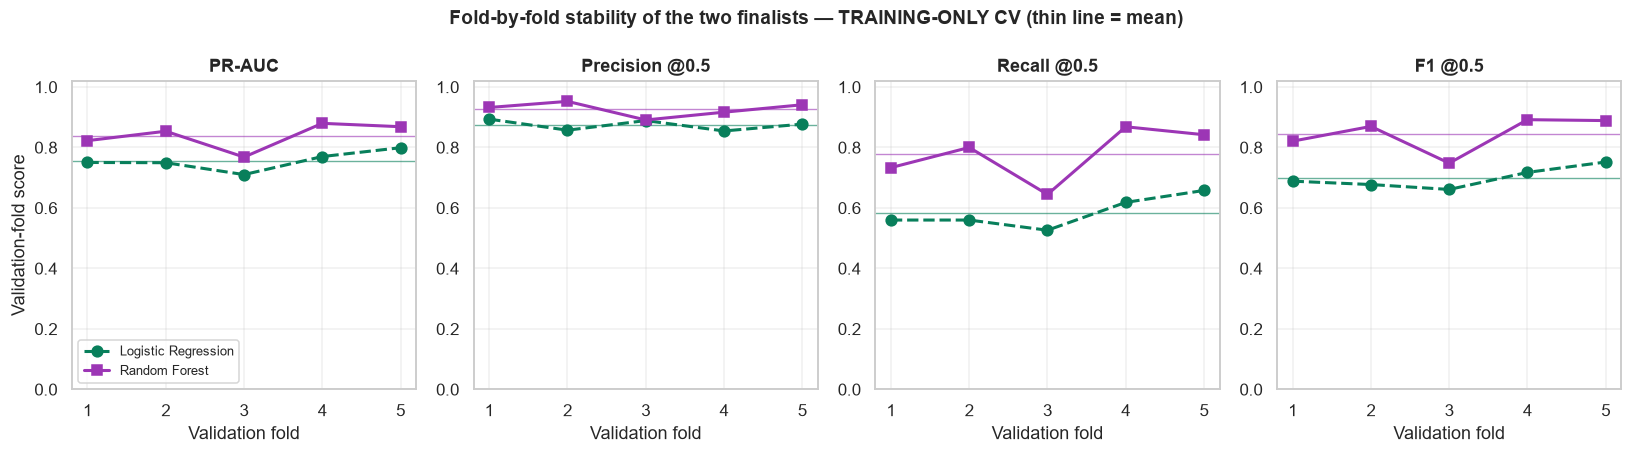

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharex=True)
for ax, metric in zip(axes, ["pr_auc", "precision", "recall", "f1"]):
    for model, name in FINALISTS.items():
        fm = cv_results[name].fold_metrics[metric]
        ax.plot(fm.index, fm.to_numpy(), color=FINALIST_COLOR[model], marker=MODEL_MARKER[model],
                ls="--" if model == "logistic_regression" else "-", linewidth=2, markersize=7,
                label=mt.MODEL_LABELS[model])
        ax.axhline(fm.mean(), color=FINALIST_COLOR[model], linewidth=0.9, alpha=0.6)
    ax.set_title({"pr_auc": "PR-AUC", "precision": "Precision @0.5", "recall": "Recall @0.5", "f1": "F1 @0.5"}[metric])
    ax.set_xticks(range(1, 6))
    ax.set_xlabel("Validation fold")
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel("Validation-fold score")
axes[0].legend(fontsize=8.5, loc="lower left", frameon=True)
fig.suptitle("Fold-by-fold stability of the two finalists — TRAINING-ONLY CV (thin line = mean)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "24_cv_fold_stability.png")
plt.show()

**Fold-by-fold.** The candidate forest's validation PR-AUC ranges **0.768254 (fold 3) – 0.879792 (fold 4)**; mean **0.838580**, std **0.044807**, descriptive 95% interval **[0.782945, 0.894215]**. Recall at 0.5 is the least stable metric (**0.644737–0.868421**, std **0.090171**) — with 75–76 frauds per fold, one fraud moves recall by ~1.3 points. Precision is steadier (**0.890909–0.952381**).

The tuned logistic regression is somewhat more stable in PR-AUC (std **0.032483**) but lower in every fold: **the forest beats it in all five folds**, by **0.058–0.110** PR-AUC. That paired, fold-by-fold result is stronger evidence than the overlapping intervals (forest [0.7829, 0.8942] vs logistic regression [0.7155, 0.7962]) suggest on their own.

Fold 3 is the weakest fold for both finalists — a harder mix of frauds, not a model-specific failure.

**Caveat.** The intervals come from five folds that share ~75% of their training data. They describe fold-to-fold spread and are likely too narrow; they are not a guarantee about unseen data.

---
## 13. Overfitting Analysis

TRAIN-fold metrics are computed on each fold's own training rows (never the resampled set) and
compared with the validation fold. They are **not** used for selection.

In [39]:
gap_rows = []
for name, r in cv_results.items():
    if r.train_fold_metrics.empty:
        continue
    gap_rows.append({"configuration": name,
                     "TRAIN-fold PR-AUC": r.train_fold_metrics["pr_auc"].mean(),
                     "validation PR-AUC": r.fold_metrics["pr_auc"].mean(),
                     "PR-AUC gap": r.train_fold_metrics["pr_auc"].mean() - r.fold_metrics["pr_auc"].mean(),
                     "TRAIN-fold recall": r.train_fold_metrics["recall"].mean(),
                     "validation recall": r.fold_metrics["recall"].mean(),
                     "recall gap": r.train_fold_metrics["recall"].mean() - r.fold_metrics["recall"].mean()})
gap_table = pd.DataFrame(gap_rows).set_index("configuration").sort_values("PR-AUC gap", ascending=False)
gap_table

,TRAIN-fold PR-AUC,validation PR-AUC,PR-AUC gap,TRAIN-fold recall,validation recall,recall gap
configuration,,,,,,
RF | standard | oversampling,1.000000,0.833136,0.166864,1.000000,0.777684,0.222316
RF | minimal | original,1.000000,0.833427,0.166573,1.000000,0.772456,0.227544
RF | standard | original,1.000000,0.834131,0.165869,1.000000,0.775088,0.224912
RF | log_amount | original,1.000000,0.834158,0.165842,1.000000,0.775088,0.224912
RF | standard | class weights,1.000000,0.834693,0.165307,1.000000,0.788246,0.211754
RF | standard | SMOTE,1.000000,0.842494,0.157506,1.000000,0.822737,0.177263
RF tuned | standard | original | 100 trees,0.972575,0.838580,0.133995,0.828698,0.777719,0.050978
RF tuned | standard | original | 300 trees,0.973404,0.840258,0.133146,0.827373,0.783018,0.044356
RF | standard | undersampling,0.838665,0.757917,0.080748,1.000000,0.894140,0.105860


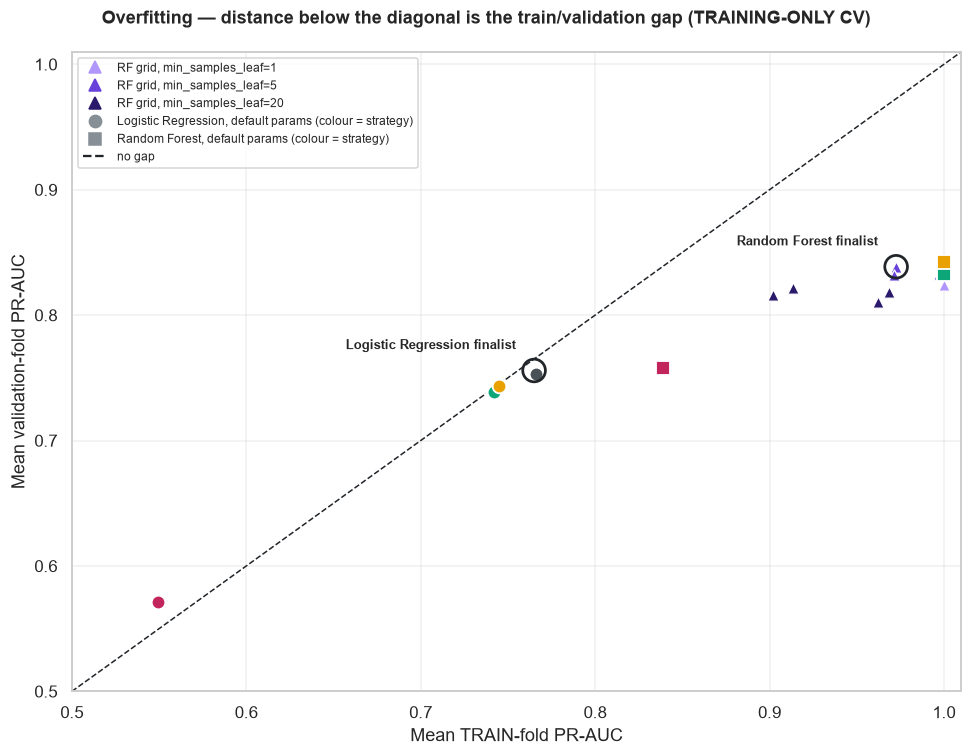

In [40]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0.5, 1.01], [0.5, 1.01], color="#212529", ls="--", linewidth=1, label="no gap (train = validation)")
leaf_colors = {1: "#b197fc", 5: "#6741d9", 20: "#2b1a6b"}   # one hue, light -> dark = more regularised
for r in rf_search.itertuples():
    ax.scatter(r.mean_train_pr_auc, r.mean_test_pr_auc, s=55, marker="^", color=leaf_colors[int(r.min_samples_leaf)],
               edgecolor="white", linewidth=0.8, zorder=3)
for name in list(LR_IMB_NAMES.values()) + list(RF_IMB_NAMES.values()):
    r = cv_results[name]
    model = config_meta[name]["model"]
    ax.scatter(r.train_fold_metrics["pr_auc"].mean(), r.fold_metrics["pr_auc"].mean(), s=80,
               marker=MODEL_MARKER[model], color=STRATEGY_STYLE[config_meta[name]["strategy"]]["color"],
               edgecolor="white", linewidth=1.2, zorder=4)
for model, name in FINALISTS.items():
    r = cv_results[name]
    x, yv = r.train_fold_metrics["pr_auc"].mean(), r.fold_metrics["pr_auc"].mean()
    ax.scatter(x, yv, s=220, facecolor="none", edgecolor="#212529", linewidth=1.8, zorder=5)
    ax.annotate(f"{mt.MODEL_LABELS[model]} finalist", xy=(x, yv), xytext=(-12, 14), textcoords="offset points",
                ha="right", fontsize=8.5, fontweight="bold")
handles = [Line2D([], [], marker="^", color=c, linestyle="none", markersize=8, label=f"RF grid, min_samples_leaf={k}")
           for k, c in leaf_colors.items()]
handles += [Line2D([], [], marker=MODEL_MARKER[m], color="#868e96", linestyle="none", markersize=8,
                   label=f"{mt.MODEL_LABELS[m]}, default params (colour = strategy)") for m in mt.MODELS]
handles += [Line2D([], [], color="#212529", ls="--", label="no gap")]
ax.legend(handles=handles, fontsize=8, loc="upper left", frameon=True)
ax.set_xlabel("Mean TRAIN-fold PR-AUC")
ax.set_ylabel("Mean validation-fold PR-AUC")
_floor = min(0.5, min(r.fold_metrics["pr_auc"].mean() for r in cv_results.values()) - 0.03,
             float(rf_search["mean_test_pr_auc"].min()) - 0.03)
ax.set_xlim(_floor, 1.01)
ax.set_ylim(_floor, 1.01)
fig.suptitle("Overfitting — distance below the diagonal is the train/validation gap (TRAINING-ONLY CV)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "18_cv_overfitting_gap.png")
plt.show()

**The regularised forest closes most of the gap.**

| | TRAIN-fold PR-AUC | validation PR-AUC | PR-AUC gap | recall gap |
|---|---|---|---|---|
| Default forests (original / weighted / oversampled / SMOTE) | 1.000000 | 0.833–0.842 | 0.158–0.167 | 0.177–0.225 |
| **Tuned forest (leaf 5, max_features 0.3)** | **0.972575** | **0.838580** | **0.133995** | **0.050978** |
| Logistic regression (non-undersampled) | 0.742–0.768 | 0.737–0.756 | 0.001–0.013 | 0.008–0.023 |

The tuned forest still scores higher on its training folds than on validation — a forest always will — but its recall gap falls from ~0.22 to **0.05**, and it achieves that at equal-or-better validation PR-AUC. Logistic regression shows essentially no gap.

The three undersampled logistic regressions show a *negative* gap (about −0.02). That is not a paradox: each was fitted on 604–606 rows, and its "TRAIN-fold" score is computed on all ~181,600 rows of the fold, most of which it never saw. TRAIN-fold metrics were recorded for this analysis only; none of them was used for selection.

---
## 14. Candidate Final Model

Rule 2 is applied to **every configuration cross-validated in this notebook** (the 15 logistic-regression
scaling × imbalance runs, the 5 default random forests, and the tuned finalists). The scaling-invariance
reruns in section 8.1 are excluded because they are, by construction, duplicates of a run already in the
pool.

In [41]:
pool_names = (list(LR_SCALING_NAMES.values()) + list(RF_IMB_NAMES.values()) + [LR_FINALIST, rf100, rf300]
              + [n for n in cv_results if n.startswith("RF | ") and "SMOTE" in n and n not in RF_IMB_NAMES.values()])
pool = summary_table(list(dict.fromkeys(pool_names)))
CANDIDATE, POOL_BEST, POOL_SE, pool_eligible = one_se_choice(pool)
print(f"configurations in the pool      : {len(pool)}")
print(f"highest mean CV PR-AUC           : {POOL_BEST}  ({pool.loc[POOL_BEST, 'pr_auc_mean']:.6f})")
print(f"one standard error of the best   : {POOL_SE:.6f}")
print(f"eligible within 1 SE             : {list(pool_eligible.index)}")
print()
print("CANDIDATE FINAL MODEL (Rule 2)   :", CANDIDATE)

configurations in the pool      : 23
highest mean CV PR-AUC           : RF | standard | SMOTE  (0.842494)
one standard error of the best   : 0.014373
eligible within 1 SE             : ['RF tuned | standard | original | 100 trees', 'RF | standard | class weights', 'RF | standard | original', 'RF tuned | standard | original | 300 trees', 'RF | standard | oversampling', 'RF | standard | SMOTE']

CANDIDATE FINAL MODEL (Rule 2)   : RF tuned | standard | original | 100 trees


### Visualisation 17 — every cross-validated configuration

Mean CV PR-AUC with the five individual fold scores. The shaded band is the Rule 2 eligibility zone
(best mean minus one standard error).

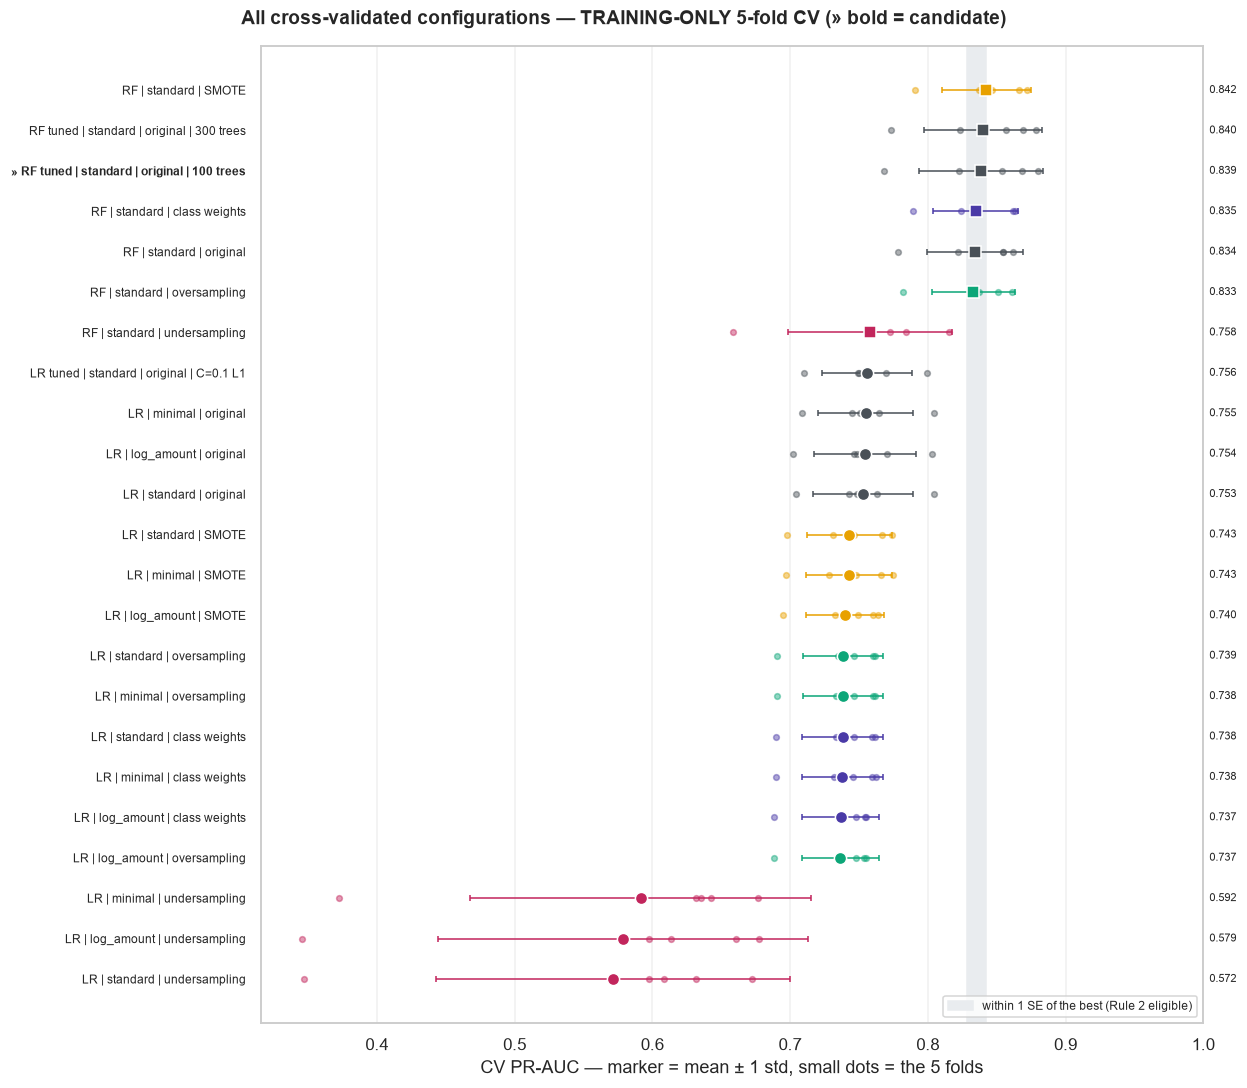

In [42]:
ranked = pool.sort_values("pr_auc_mean")
fig, ax = plt.subplots(figsize=(11.5, 0.36 * len(ranked) + 1.8))
ax.axvspan(pool.loc[POOL_BEST, "pr_auc_mean"] - POOL_SE, pool.loc[POOL_BEST, "pr_auc_mean"], color="#e9ecef",
           zorder=1, label="within 1 SE of the best (Rule 2 eligible)")
for i, name in enumerate(ranked.index):
    meta = config_meta[name]
    folds_pr = cv_results[name].fold_metrics["pr_auc"].to_numpy()
    color = STRATEGY_STYLE[meta["strategy"]]["color"]
    ax.scatter(folds_pr, [i] * len(folds_pr), s=14, color=color, alpha=0.45, zorder=3)
    ax.errorbar(ranked.loc[name, "pr_auc_mean"], i, xerr=ranked.loc[name, "pr_auc_std"], fmt=MODEL_MARKER[meta["model"]],
                color=color, markersize=8, markeredgecolor="white", capsize=2, elinewidth=1, zorder=4)
    ax.annotate(f"{ranked.loc[name, 'pr_auc_mean']:.3f}", xy=(1.0, i), xycoords=("axes fraction", "data"),
                xytext=(4, 0), textcoords="offset points", va="center", fontsize=7.5)
ax.set_yticks(range(len(ranked)), [("» " if n == CANDIDATE else "") + n for n in ranked.index], fontsize=7.8)
for tick in ax.get_yticklabels():
    if tick.get_text().startswith("» "):
        tick.set_fontweight("bold")
ax.set_xlabel("CV PR-AUC — marker = mean ± 1 std, small dots = the 5 folds")
ax.set_xlim(min(0.45, min(cv_results[n].fold_metrics["pr_auc"].min() for n in ranked.index) - 0.03), 1.0)
ax.legend(loc="lower right", fontsize=8, frameon=True)
ax.grid(axis="y", visible=False)
fig.suptitle("All cross-validated configurations — TRAINING-ONLY 5-fold CV (» bold = candidate)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "17_cv_model_comparison.png")
plt.show()

In [43]:
cand_meta = config_meta[CANDIDATE]
cand_model = cand_meta["model"]
cand_summary = cv_results[CANDIDATE].summary()
if CANDIDATE in FINALISTS.values():
    cand_threshold_info = threshold_results[cand_model]
else:
    t, tab, edge = choose_threshold(y_train.to_numpy(), cv_results[CANDIDATE].oof_proba.to_numpy())
    cand_threshold_info = {"threshold": t, "table": tab, "edge": edge}
CANDIDATE_THRESHOLD = cand_threshold_info["threshold"]
cand_row = cand_threshold_info["table"].loc[CANDIDATE_THRESHOLD]
cand_pipeline = mt.build_pipeline(cand_model, cand_meta["strategy"], scaling=cand_meta["scaling"],
                                  classifier_params=cand_meta["classifier_params"])
cand_clf_params = cand_pipeline.named_steps["classifier"].get_params()

OOF_FINGERPRINT = hashlib.sha256(np.ascontiguousarray(cv_results[CANDIDATE].oof_proba.to_numpy()).tobytes()).hexdigest()

print("=" * 78)
print("CANDIDATE FINAL MODEL  (not final - Phase 5 evaluates it once on the untouched test set)")
print("=" * 78)
print(f"configuration     : {CANDIDATE}")
print(f"model             : {mt.MODEL_LABELS[cand_model]}")
print(f"preprocessing     : {cand_meta['scaling']}")
print(f"imbalance         : {mt.STRATEGY_LABELS[cand_meta['strategy']]}")
print(f"pipeline steps    : {' -> '.join(cand_pipeline.named_steps)}")
print("hyperparameters   :", {k: cand_clf_params[k] for k in sorted(cand_clf_params)
                              if k in ("C", "l1_ratio", "solver", "max_iter", "class_weight", "n_estimators",
                                       "max_depth", "min_samples_leaf", "max_features", "random_state", "n_jobs")})
print("-" * 78)
print("TRAINING-ONLY 5-fold CV at threshold 0.5:")
for m in ("pr_auc", "precision", "recall", "f1", "roc_auc"):
    print(f"  {m:<10} mean {cand_summary[m + '_mean']:.6f}  std {cand_summary[m + '_std']:.6f}  "
          f"descriptive 95% interval [{cand_summary[m + '_ci_low']:.6f}, {cand_summary[m + '_ci_high']:.6f}]")
print("-" * 78)
print(f"CANDIDATE OPERATING THRESHOLD: {CANDIDATE_THRESHOLD:.2f}  (Rule 3, out-of-fold, max F1)"
      + (f"  [grid extended at {cand_threshold_info['edge']} edge]" if cand_threshold_info["edge"] else ""))
print(f"  OOF precision {cand_row['precision']:.6f} | recall {cand_row['recall']:.6f} | F1 {cand_row['f1']:.6f}")
print(f"  OOF false positives {int(cand_row['fp']):,} | false negatives {int(cand_row['fn'])} | "
      f"true positives {int(cand_row['tp'])}  (of 378 training frauds, 226,602 legitimate)")
print(f"OOF fingerprint   : {OOF_FINGERPRINT[:32]}")
print("=" * 78)

CANDIDATE FINAL MODEL  (not final - Phase 5 evaluates it once on the untouched test set)
configuration     : RF tuned | standard | original | 100 trees
model             : Random Forest
preprocessing     : standard
imbalance         : Original distribution
pipeline steps    : preprocess -> classifier
hyperparameters   : {'class_weight': None, 'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 5, 'n_estimators': 100, 'n_jobs': -1, 'random_state': 42}
------------------------------------------------------------------------------
TRAINING-ONLY 5-fold CV at threshold 0.5:
  pr_auc     mean 0.838580  std 0.044807  descriptive 95% interval [0.782945, 0.894215]
  precision  mean 0.926667  std 0.023880  descriptive 95% interval [0.897016, 0.956318]
  recall     mean 0.777719  std 0.090171  descriptive 95% interval [0.665757, 0.889681]
  f1         mean 0.843867  std 0.060610  descriptive 95% interval [0.768609, 0.919124]
  roc_auc    mean 0.953749  std 0.022195  descriptive 95% interv

### Visualisation 22 — threshold analysis for the candidate

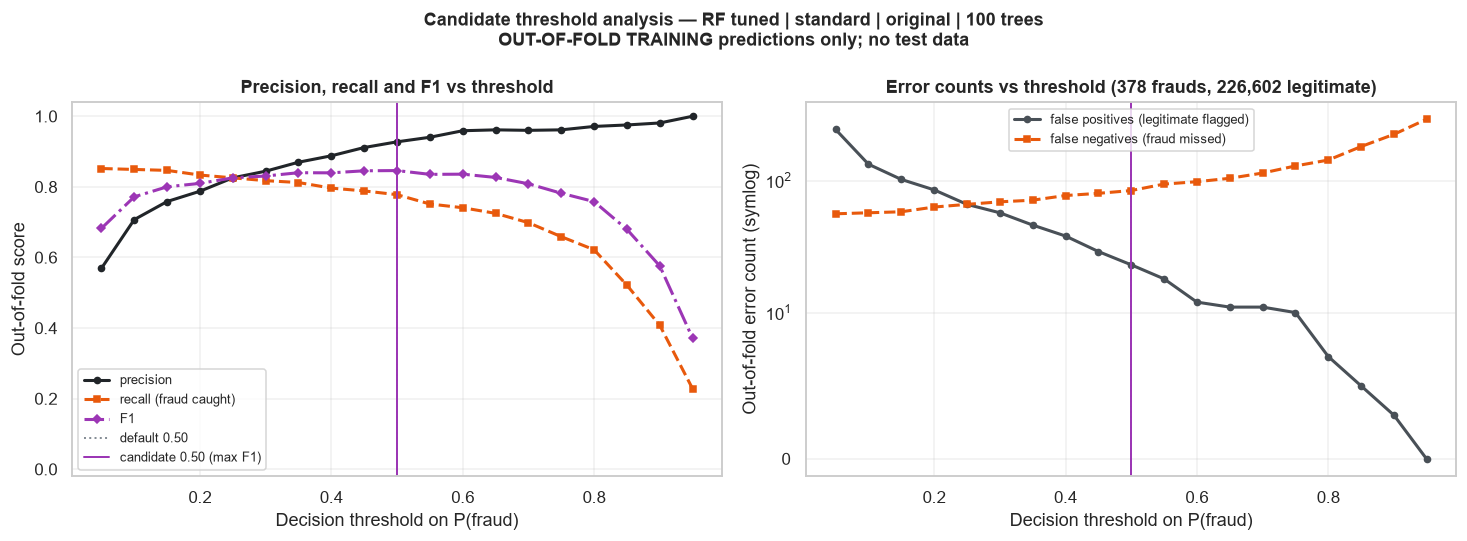

In [44]:
tab = cand_threshold_info["table"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
ax = axes[0]
ax.plot(tab.index, tab["precision"], color="#212529", ls="-", marker="o", markersize=4, linewidth=2, label="precision")
ax.plot(tab.index, tab["recall"], color=C_FRAUD, ls="--", marker="s", markersize=4, linewidth=2, label="recall (fraud caught)")
ax.plot(tab.index, tab["f1"], color=FINALIST_COLOR[cand_model], ls="-.", marker="D", markersize=4, linewidth=2, label="F1")
ax.axvline(0.5, color="#868e96", ls=":", linewidth=1.3, label="default 0.50")
ax.axvline(CANDIDATE_THRESHOLD, color=FINALIST_COLOR[cand_model], ls="-", linewidth=1.3,
           label=f"candidate {CANDIDATE_THRESHOLD:.2f} (max F1)")
ax.set_xlabel("Decision threshold on P(fraud)")
ax.set_ylabel("Out-of-fold score")
ax.set_ylim(-0.02, 1.04)
ax.legend(fontsize=8.5, frameon=True, loc="lower left")
ax.set_title("Precision, recall and F1 vs threshold")
ax = axes[1]
ax.plot(tab.index, tab["fp"], color="#495057", marker="o", markersize=4, linewidth=2, label="false positives (legitimate flagged)")
ax.plot(tab.index, tab["fn"], color=C_FRAUD, marker="s", markersize=4, ls="--", linewidth=2, label="false negatives (fraud missed)")
ax.set_yscale("symlog", linthresh=10)
ax.axvline(0.5, color="#868e96", ls=":", linewidth=1.3)
ax.axvline(CANDIDATE_THRESHOLD, color=FINALIST_COLOR[cand_model], ls="-", linewidth=1.3)
ax.set_xlabel("Decision threshold on P(fraud)")
ax.set_ylabel("Out-of-fold error count (symlog)")
ax.legend(fontsize=8.5, frameon=True, loc="upper center")
ax.set_title("Error counts vs threshold (378 frauds, 226,602 legitimate)")
fig.suptitle(f"Candidate threshold analysis — {CANDIDATE}\nOUT-OF-FOLD TRAINING predictions only; no test data",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "22_precision_recall_threshold_analysis.png")
plt.show()

---
## 15. Selection Rationale

In [45]:
facts = pool[["model", "imbalance", "pr_auc_mean", "pr_auc_std", "recall_mean", "precision_mean", "f1_mean",
              "fit s (5 folds)"]].copy()
facts["within 1 SE of best"] = facts.index.isin(pool_eligible.index)
facts = facts.sort_values("pr_auc_mean", ascending=False).head(8)
print("Top 8 configurations by mean CV PR-AUC (TRAINING-ONLY CV, threshold 0.5 for precision/recall/F1)")
facts

Top 8 configurations by mean CV PR-AUC (TRAINING-ONLY CV, threshold 0.5 for precision/recall/F1)


,model,imbalance,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit s (5 folds),within 1 SE of best
configuration,,,,,,,,,
RF | standard | SMOTE,Random Forest,SMOTE,0.842494,0.032139,0.822737,0.892634,0.855322,586.075442,True
RF tuned | standard | original | 300 trees,Random Forest,Original distribution,0.840258,0.042840,0.783018,0.927531,0.846989,"1,255.370486",True
RF tuned | standard | original | 100 trees,Random Forest,Original distribution,0.838580,0.044807,0.777719,0.926667,0.843867,507.388385,True
RF | standard | class weights,Random Forest,Class weights (balanced),0.834693,0.030683,0.788246,0.921052,0.848139,114.488597,True
RF | standard | original,Random Forest,Original distribution,0.834131,0.034962,0.775088,0.942724,0.848777,285.119960,True
RF | standard | oversampling,Random Forest,Random oversampling,0.833136,0.030456,0.777684,0.934691,0.847559,281.221163,True
RF | standard | undersampling,Random Forest,Random undersampling,0.757917,0.059472,0.894140,0.069568,0.128953,2.624219,False
LR tuned | standard | original | C=0.1 L1,Logistic Regression,Original distribution,0.755871,0.032483,0.584526,0.874277,0.699308,14.280721,False


**How the candidate was chosen — by Rule 2, from CV results only.**

1. **Highest mean CV PR-AUC** in the pool of 23 configurations: the default forest with SMOTE, **0.842494** (one standard error **0.014373**).
2. **Eligible within one standard error:** six random forests — SMOTE, tuned (100 and 300 trees), class weights, original and oversampling. No logistic regression comes close (best **0.755871**, about six standard errors below).
3. **Simplest eligible by the declared order:** the forest family is fixed; among imbalance options, the three no-resampling forests (tuned-100, class weights, original) rank simplest; among those, 100 trees; all use `standard` scaling; the tie-break (higher mean) selects **the tuned forest, 0.838580**.

**Facts about the decision, stated without a combined score:**

* The candidate's mean CV PR-AUC is **0.0039** below the SMOTE forest's — about a quarter of a standard error.
* At the default threshold the SMOTE forest catches more fraud (recall **0.822737** vs **0.777719**) and raises more false alarms (precision **0.892634** vs **0.926667**). That is an operating-point difference, which section 11 shows the candidate can reproduce by lowering its threshold (at 0.35: recall **0.812169**, precision **0.869688**).
* The candidate needs **no resampling** — no synthetic transactions, one fewer fitted step, nothing for scaling to perturb.
* It overfits least among the forests: recall gap **0.051** vs **0.177** for the SMOTE forest.
* It beats the tuned logistic regression in **all five folds**.
* Cost is comparable: **~121–123 s** vs **~136–140 s** for five folds.

The decision was made by a rule written before the results existed. The candidate is **not** declared better than the SMOTE forest: the data does not distinguish them, and Rule 2 resolves such ties in favour of the simpler pipeline.

### Relationship to the Phase 3 baseline

The table below places the Phase 3 numbers beside the Phase 4 numbers **for the same ten default
configurations**. They are **not** equivalent evaluations and must not be compared as a contest:

* **PHASE 3 — previously observed holdout baseline.** One score on 56,746 test rows (95 frauds),
  recorded once in Phase 3 and copied here verbatim. *Not recomputed* — this notebook computes no test
  metric.
* **PHASE 4 — training-only cross-validation.** Mean of five validation folds of ~45,400 rows
  (75–76 frauds each), drawn from the training split.

Phase 3's numbers remain a useful historical baseline. Only Phase 4's drive selection.

In [46]:
# Copied verbatim from the executed Phase 3 notebook (section 15.1). NOT recomputed here.
PHASE3_HOLDOUT_BASELINE = {
    ("logistic_regression", "original"):     {"pr_auc": 0.691967, "recall": 0.578947, "precision": 0.846154},
    ("logistic_regression", "class_weight"): {"pr_auc": 0.671924, "recall": 0.873684, "precision": 0.056386},
    ("logistic_regression", "oversample"):   {"pr_auc": 0.668936, "recall": 0.873684, "precision": 0.056540},
    ("logistic_regression", "smote"):        {"pr_auc": 0.675041, "recall": 0.873684, "precision": 0.053035},
    ("logistic_regression", "undersample"):  {"pr_auc": 0.589557, "recall": 0.873684, "precision": 0.050425},
    ("random_forest", "original"):           {"pr_auc": 0.787618, "recall": 0.726316, "precision": 0.971831},
    ("random_forest", "class_weight"):       {"pr_auc": 0.801196, "recall": 0.726316, "precision": 0.945205},
    ("random_forest", "oversample"):         {"pr_auc": 0.802386, "recall": 0.726316, "precision": 0.958333},
    ("random_forest", "smote"):              {"pr_auc": 0.811967, "recall": 0.768421, "precision": 0.912500},
    ("random_forest", "undersample"):        {"pr_auc": 0.698284, "recall": 0.873684, "precision": 0.084780},
}
rows = []
for (model, strategy), p3 in PHASE3_HOLDOUT_BASELINE.items():
    name = LR_SCALING_NAMES[("standard", strategy)] if model == "logistic_regression" else RF_IMB_NAMES[strategy]
    s = cv_results[name].summary()
    rows.append({"model": mt.MODEL_LABELS[model], "imbalance": mt.STRATEGY_LABELS[strategy],
                 "PHASE 3 holdout PR-AUC": p3["pr_auc"], "PHASE 4 CV PR-AUC mean": s["pr_auc_mean"],
                 "PHASE 4 CV PR-AUC std": s["pr_auc_std"],
                 "PHASE 3 holdout recall": p3["recall"], "PHASE 4 CV recall mean": s["recall_mean"],
                 "PHASE 3 holdout precision": p3["precision"], "PHASE 4 CV precision mean": s["precision_mean"]})
phase_comparison = pd.DataFrame(rows).set_index(["model", "imbalance"])
p3_rank = phase_comparison["PHASE 3 holdout PR-AUC"].rank(ascending=False)
p4_rank = phase_comparison["PHASE 4 CV PR-AUC mean"].rank(ascending=False)
print("Spearman rank agreement between the Phase 3 holdout ordering and the Phase 4 CV ordering:",
      f"{p3_rank.corr(p4_rank, method='spearman'):.3f}")
phase_comparison

Spearman rank agreement between the Phase 3 holdout ordering and the Phase 4 CV ordering: 0.952


PHASE 3 holdout PR-AUC  PHASE 4 CV PR-AUC mean  PHASE 4 CV PR-AUC std  PHASE 3 holdout recall  PHASE 4 CV recall mean  \
model               imbalance                                                                                                                                         
Logistic Regression Original distribution                   0.691967                0.752709               0.036378                0.578947                0.605649   
                    Class weights (balanced)                0.671924                0.738234               0.029436                0.873684                0.917895   
                    Random oversampling                     0.668936                0.738726               0.029007                0.873684                0.915263   
                    SMOTE                                   0.675041                0.743121               0.030637                0.873684                0.907298   
                    Random undersampling                    0.589557                0.571517               0.128634                0.873684                0.912632   
Random Forest       Original distribution                   0.787618                0.834131               0.034962                0.726316                0.775088   
                    Class weights (balanced)                0.801196                0.834693               0.030683                0.726316                0.788246   
                    Random oversampling                     0.802386                0.833136               0.030456                0.726316                0.777684   
                    SMOTE                                   0.811967                0.842494               0.032139                0.768421                0.822737   
                    Random undersampling                    0.698284                0.757917               0.059472                0.873684                0.894140   

                                              PHASE 3 holdout precision  PHASE 4 CV precision mean  
model               imbalance                                                                       
Logistic Regression Original distribution                      0.846154                   0.863288  
                    Class weights (balanced)                   0.056386                   0.060535  
                    Random oversampling                        0.056540                   0.060884  
                    SMOTE                                      0.053035                   0.054983  
                    Random undersampling                       0.050425                   0.043027  
Random Forest       Original distribution                      0.971831                   0.942724  
                    Class weights (balanced)                   0.945205                   0.921052  
                    Random oversampling                        0.958333                   0.934691  
                    SMOTE                                      0.912500                   0.892634  
                    Random undersampling                       0.084780                   0.069568

**Two evaluations, not one contest.** The orderings agree closely — **Spearman ρ = 0.952** between the Phase 3 holdout PR-AUC ranking and the Phase 4 CV ranking of the same ten configurations. The forest-over-logistic-regression gap, the collapse under undersampling, and "rebalancing moves recall, not ranking" all reappear on training data alone.

The **levels** differ: CV means are higher than the Phase 3 holdout scores for nine of ten configurations (e.g. SMOTE forest **0.842494** CV vs **0.811967** holdout; logistic regression original **0.752709** vs **0.691967**). That is not an improvement and must not be read as one. The holdout is a single draw of 95 frauds — Phase 3 found 11 of them are missed by every configuration — while each CV value is an average over five validation folds of 75–76 frauds from a different set of rows. A one-sample holdout can easily sit below a CV average by this much.

Phase 5 will score the candidate once on the untouched test set. If its test PR-AUC lands nearer the Phase 3 levels than the CV levels, that would be consistent with the test split simply being harder, not with the candidate having failed.

---
## 16. Test-Set Isolation Verification

Three independent lines of evidence, then the full validation suite.

1. **Data evidence** — the test split is re-derived and compared, byte for byte, with the fingerprint
   recorded at the lock in section 3 *and* the fingerprint Phase 3 recorded.
2. **Row evidence** — every row scored by a search scorer, every out-of-fold prediction and every fitted
   scaler/sampler is checked against the test row labels.
3. **Code evidence** — this notebook reads its own source from disk and confirms that the test split is
   referenced only in the two cells marked as isolation cells (section 3 and this one).

In [47]:
# TEST-ISOLATION CELL - verification only. No prediction or metric is computed on these rows.
_verify_split = dp.split_data(dp.load_data())
TEST_FINGERPRINT_AFTER = frame_fingerprint(_verify_split.X_test, _verify_split.y_test)
TEST_ROWS_AFTER = len(_verify_split.X_test)
TEST_COUNTS_AFTER = _verify_split.y_test.value_counts().sort_index().to_dict()
TEST_ORDER_UNCHANGED = _verify_split.X_test.index.equals(TEST_INDEX)
TRAIN_UNCHANGED = _verify_split.X_train.index.equals(TRAIN_INDEX) and frame_fingerprint(
    _verify_split.X_train, _verify_split.y_train) == frame_fingerprint(X_train, y_train)
del _verify_split
test_labels = set(TEST_INDEX.tolist())
print("test fingerprint at lock :", TEST_FINGERPRINT_LOCK)
print("test fingerprint now     :", TEST_FINGERPRINT_AFTER)
print("Phase 3 recorded         :", PHASE3_TEST_FINGERPRINT)

test fingerprint at lock : 50a7a7a9ab2a1efdb5ed371e35593bd19f04a3276b08ce31ef3a51017187f27e
test fingerprint now     : 50a7a7a9ab2a1efdb5ed371e35593bd19f04a3276b08ce31ef3a51017187f27e
Phase 3 recorded         : 50a7a7a9ab2a1efdb5ed371e35593bd19f04a3276b08ce31ef3a51017187f27e


In [48]:
# Code evidence: scan this notebook's own source for any reference to the test split.
source_cells = json.loads(NOTEBOOK_PATH.read_text(encoding="utf-8"))["cells"]
test_tokens = ("X_test", "y_test", "TEST_INDEX", ".X_test", ".y_test")
offending = []
for i, cell in enumerate(source_cells):
    if cell["cell_type"] != "code":
        continue
    src = "".join(cell["source"])
    if src.lstrip().startswith("# TEST-ISOLATION CELL"):
        continue
    lines = [ln for ln in src.splitlines() if any(tok in ln for tok in test_tokens)
             and not ln.strip().startswith("#") and "test_tokens" not in ln and "TEST_INDEX.tolist()" not in ln]
    if lines:
        offending.append((i, lines))
isolation_cells = sum(1 for c in source_cells if c["cell_type"] == "code"
                      and "".join(c["source"]).lstrip().startswith("# TEST-ISOLATION CELL"))
print(f"code cells scanned: {sum(1 for c in source_cells if c['cell_type'] == 'code')} | "
      f"marked isolation cells: {isolation_cells} | cells referencing the test split elsewhere: {len(offending)}")
for i, lines in offending:
    print("  cell", i, lines)

code cells scanned: 53 | marked isolation cells: 2 | cells referencing the test split elsewhere: 0


### 16.0 Determinism of random-forest predictions

A first final execution of this notebook **failed its validation suite** (check 25, below): the forest
search winner's per-fold PR-AUC did not reproduce exactly when re-run. A second execution of the identical
code passed — the signature of non-determinism. The cause was isolated on training data:
`RandomForestClassifier.predict_proba` with `n_jobs=-1` adds the trees' probabilities into a shared array in
whatever order the threads finish, and floating-point addition is not associative. On one fitted forest,
**20 of 20** repeated calls differed from the first by up to 2.2e-16 — enough to reorder tied scores or flip
a score sitting exactly on a threshold.

The fix, in `src/model_training.py`, is `FixedOrderRandomForestClassifier`: training stays parallel (each tree
has its own pre-drawn seed, so `fit` was already deterministic) and prediction sums the trees in the fixed
order of `estimators_` (0.2 s for a 45,396-row fold). Phase 3 is unaffected: its fully grown forests have pure
leaves, so every per-tree probability is exactly 0 or 1 and the sums were already exact — which is why Phase 3
reproduced bit-for-bit, and why plain scikit-learn and the fixed-order class return identical values for them.

The cell below makes that a recorded check rather than a claim: the candidate pipeline is fitted on one
training fold and its predictions repeated.

In [49]:
# Training data only: fold 1 of the shared splitter.
_tr, _va = next(cv.split(X_train, y_train))
_det_pipe = mt.build_pipeline(cand_model, cand_meta["strategy"], scaling=cand_meta["scaling"],
                              classifier_params=cand_meta["classifier_params"]).fit(X_train.iloc[_tr], y_train.iloc[_tr])
_first = _det_pipe.predict_proba(X_train.iloc[_va])[:, 1]
DETERMINISTIC_REPEATS = [bool(np.array_equal(_first, _det_pipe.predict_proba(X_train.iloc[_va])[:, 1])) for _ in range(5)]
CAND_CLASSIFIER_CLASS = type(_det_pipe.named_steps["classifier"]).__name__
del _det_pipe, _first, _tr, _va
print("candidate classifier class       :", CAND_CLASSIFIER_CLASS)
print("5 repeated predictions identical :", DETERMINISTIC_REPEATS)

candidate classifier class       : FixedOrderRandomForestClassifier
5 repeated predictions identical : [True, True, True, True, True]


In [50]:
all_cv = list(cv_results.values())
oof_rows_scored = set()
for r in all_cv:
    oof_rows_scored.update(r.oof_proba.index.tolist())

expected_fold_train = [int(n) for n in folds["train rows"]]
sampler_ok = True
for r in all_cv:
    for strat, counts in zip(r.sampler_strategies, r.fold_train_counts):
        if strat is None:
            continue
        expected = ({1: counts[0] - counts[1]} if 1 in strat else {0: counts[1]})
        sampler_ok &= (strat == expected)
scaler_ok = all(all(seen == size for seen in fold_seen) for r in all_cv
                for fold_seen, size in zip(r.scaler_samples_seen, r.fold_train_sizes))
scaler_below_train = all(size < len(X_train) for r in all_cv for size in r.fold_train_sizes)

cand = cv_results[CANDIDATE]
conv = [w for r in all_cv for w in r.warnings if w[1] == "ConvergenceWarning"]
conv += [w for w in lr_search_warnings if w[1] == "ConvergenceWarning"]
# Only artefacts written during this run count: the locked Phase 5 model (models/*.joblib) exists by design
# once Phase 5 has run, and must not make this phase's "no artefact written" check fail.
model_artifacts = [p for p in list(PROJECT_DIR.rglob("*.joblib")) + list(PROJECT_DIR.rglob("*.pkl"))
                   if p.stat().st_mtime >= NOTEBOOK_START_WALL]
SHA256_FINAL = dp.sha256_of_file(dp.default_dataset_path())


def recall_by_hand(m):
    return m["tp"] / (m["tp"] + m["fn"])


def precision_by_hand(m):
    return m["tp"] / (m["tp"] + m["fp"]) if (m["tp"] + m["fp"]) else 0.0


fold_rows_all = [row for r in all_cv for _, row in r.fold_metrics.iterrows()]
checks = [
    ("1. Phase 2 split unchanged (train frame re-derived byte-identical)", TRAIN_UNCHANGED),
    ("2. training row count unchanged (226,980)", len(X_train) == 226_980),
    ("3. test row count unchanged (56,746)", TEST_ROWS_AFTER == TEST_ROWS_LOCK == 56_746),
    ("4. test class counts unchanged (56,651 / 95)", TEST_COUNTS_AFTER == TEST_COUNTS_LOCK == {0: 56_651, 1: 95}),
    ("5. stratified folds valid (75-76 fraud per validation fold, sum 378)",
     set(folds["validation fraud"]) <= {75, 76} and int(folds["validation fraud"].sum()) == 378),
    ("6. no train/validation overlap in any fold; validation folds partition the training rows",
     bool((folds["overlap"] == 0).all()) and bool((counts_per_row == 1).all())),
    ("7. every training row gets exactly one OOF prediction (candidate)",
     cand.oof_proba.notna().all() and len(cand.oof_proba) == len(X_train)
     and bool((cand.fold_of_row.value_counts() == 45_396).all())),
    ("8. OOF predictions aligned with training rows (same index, same order)",
     all(r.oof_proba.index.equals(X_train.index) for r in all_cv)),
    ("9. test rows never entered resampling (fold-derived sampler strategies)", bool(sampler_ok)),
    ("10. test rows never entered scaler fitting (n_samples_seen = fold training size < training rows)",
     scaler_ok and scaler_below_train),
    ("11. test rows never entered hyperparameter selection (every scored row is a training row)",
     len(lr_recorder.seen & test_labels) == 0 and len(rf_recorder.seen & test_labels) == 0
     and lr_recorder.seen <= set(TRAIN_INDEX) and rf_recorder.seen <= set(TRAIN_INDEX)
     and len(lr_recorder.seen) == len(X_train) and len(rf_recorder.seen) == len(X_train)),
    ("12. test rows never entered threshold selection (threshold computed from 226,980 OOF rows)",
     int(cand_threshold_info["table"][["tp", "fp", "fn", "tn"]].iloc[0].sum()) == len(X_train)
     and len(oof_rows_scored & test_labels) == 0),
    ("13. no NaN in any OOF prediction", all(r.oof_proba.notna().all() for r in all_cv)),
    ("14. no infinite OOF prediction", all(np.isfinite(r.oof_proba.to_numpy()).all() for r in all_cv)),
    ("15. probabilities within [0, 1]", all(r.oof_proba.between(0, 1).all() for r in all_cv)),
    ("16. metrics use fraud as the positive class (match TP-based hand calculation)",
     all(np.isclose(row["recall"], recall_by_hand(row)) and np.isclose(row["precision"], precision_by_hand(row))
         for row in fold_rows_all)),
    ("17. PR-AUC computed from probabilities (fold PR-AUC recomputed from OOF scores)",
     cand.oof_proba.nunique() > 2
     and all(np.isclose(cand.fold_metrics.loc[f, "pr_auc"],
                        mt.average_precision_score(y_train[cand.fold_of_row == f], cand.oof_proba[cand.fold_of_row == f]))
             for f in range(1, 6))),
    ("18. ROC-AUC computed from probabilities (fold ROC-AUC recomputed from OOF scores)",
     all(np.isclose(cand.fold_metrics.loc[f, "roc_auc"],
                    mt.roc_auc_score(y_train[cand.fold_of_row == f], cand.oof_proba[cand.fold_of_row == f]))
         for f in range(1, 6))),
    ("19. raw dataset checksum unchanged", SHA256_FINAL == SHA256_INITIAL == dp.RAW_DATASET_SHA256),
    ("20. test dataframe byte-identical to the lock and to the Phase 3 record",
     TEST_FINGERPRINT_AFTER == TEST_FINGERPRINT_LOCK == PHASE3_TEST_FINGERPRINT and TEST_ORDER_UNCHANGED),
    ("21. candidate threshold comes from OOF data only (reproduced from the OOF vector)",
     choose_threshold(y_train.to_numpy(), cand.oof_proba.to_numpy())[0] == CANDIDATE_THRESHOLD),
    ("22. candidate selection uses CV results only (Rule 2 reproduced from the CV summary table)",
     one_se_choice(summary_table(list(pool.index)))[0] == CANDIDATE),
    ("23. test split referenced only in the two marked isolation cells (source scan)",
     len(offending) == 0 and isolation_cells == 2),
    ("24. no test prediction or test metric exists (no test-scored rows anywhere)",
     len(oof_rows_scored & test_labels) == 0 and len((lr_recorder.seen | rf_recorder.seen) & test_labels) == 0),
    ("25. search winners reproduce exactly in the OOF re-runs", bool(SEARCH_RERUN_CONSISTENT)),
    ("26. random_state = 42 on the CV splitter, samplers and classifiers",
     cv.random_state == 42 and all(mt.build_pipeline(m, s).named_steps["classifier"].random_state == 42
                                   for m in mt.MODELS for s in mt.STRATEGIES)
     and all(mt.build_pipeline(m, s).named_steps["resample"].random_state == 42
             for m in mt.MODELS for s in ("oversample", "smote", "undersample"))),
    ("27. no ConvergenceWarning in any CV fit or LR search fit", len(conv) == 0),
    ("28. no model artefact written by this notebook (.joblib / .pkl)", len(model_artifacts) == 0),
    ("29. random-forest predictions bit-for-bit repeatable (fixed-order summation)",
     all(DETERMINISTIC_REPEATS) and (cand_model != "random_forest"
                                     or CAND_CLASSIFIER_CLASS == "FixedOrderRandomForestClassifier")),
]
validation = pd.DataFrame(checks, columns=["check", "passed"])
validation["status"] = np.where(validation["passed"], "PASS", "FAIL")
n_passed = int(validation["passed"].sum())
print(f"validation checks passed: {n_passed} / {len(validation)}")
assert validation["passed"].all(), "VALIDATION FAILED:\n" + validation.loc[~validation["passed"], "check"].to_string()
print()
print("Test set was not used for model selection.")
validation[["check", "status"]]

validation checks passed: 29 / 29

Test set was not used for model selection.


,check,status
0,1. Phase 2 split unchanged (train frame re-der...,PASS
1,"2. training row count unchanged (226,980)",PASS
2,"3. test row count unchanged (56,746)",PASS
3,"4. test class counts unchanged (56,651 / 95)",PASS
4,5. stratified folds valid (75-76 fraud per val...,PASS
5,6. no train/validation overlap in any fold; va...,PASS
6,7. every training row gets exactly one OOF pre...,PASS
7,8. OOF predictions aligned with training rows ...,PASS
8,9. test rows never entered resampling (fold-de...,PASS
9,10. test rows never entered scaler fitting (n_...,PASS


### 16.1 Saved Phase 4 outputs (no model artefact)

The CV summary, both search result tables, the candidate's threshold table and the candidate
configuration are written to `results/` so Phase 5 can lock exactly this configuration. Timing
columns are excluded so the files are identical across reruns. No fitted model is saved.

In [51]:
pool_out = pool.drop(columns=["fit s (5 folds)"]).copy()
pool_out.to_csv(RESULTS_DIR / "phase4_cv_summary.csv", float_format="%.10f")
lr_search.drop(columns=["mean_fit_time"]).to_csv(RESULTS_DIR / "phase4_lr_search.csv", index=False, float_format="%.10f")
rf_search.drop(columns=["mean_fit_time"]).to_csv(RESULTS_DIR / "phase4_rf_search.csv", index=False, float_format="%.10f")
cand_threshold_info["table"].to_csv(RESULTS_DIR / "phase4_candidate_threshold_analysis.csv", float_format="%.10f")

candidate_record = {
    "status": "CANDIDATE FINAL MODEL - not final until Phase 5 untouched-test evaluation",
    "selected_by": "Rule 2 (highest mean CV PR-AUC, one-standard-error rule, declared simplicity order)",
    "configuration": CANDIDATE,
    "model": cand_model,
    "scaling": cand_meta["scaling"],
    "imbalance_strategy": cand_meta["strategy"],
    "classifier_params": {k: (None if v is None else v) for k, v in cand_meta["classifier_params"].items()},
    "candidate_operating_threshold": CANDIDATE_THRESHOLD,
    "threshold_rule": "Rule 3 - max F1 on out-of-fold training predictions, grid 0.05-0.95, ties to lower",
    "cv": {"n_splits": mt.N_SPLITS, "shuffle": True, "random_state": RANDOM_STATE,
           "fold_assignment_sha256": FOLD_FINGERPRINT},
    "cv_metrics_at_0_5": {m: {"mean": float(cand_summary[f"{m}_mean"]), "std": float(cand_summary[f"{m}_std"])}
                          for m in ("pr_auc", "precision", "recall", "f1", "roc_auc")},
    "oof_at_candidate_threshold": {k: (int(cand_row[k]) if k in ("tp", "fp", "fn", "tn") else float(cand_row[k]))
                                   for k in ("precision", "recall", "f1", "tp", "fp", "fn", "tn")},
    "oof_sha256": OOF_FINGERPRINT,
    "training_rows": len(X_train),
    "test_set_used": False,
    "raw_dataset_sha256": SHA256_FINAL,
}
(RESULTS_DIR / "phase4_candidate.json").write_text(json.dumps(candidate_record, indent=2, default=str) + "\n",
                                                    encoding="utf-8")
for f in sorted(RESULTS_DIR.glob("phase4_*")):
    print(f"{f.name:<45} {f.stat().st_size:>9,} bytes  sha256 {hashlib.sha256(f.read_bytes()).hexdigest()[:16]}")

phase4_candidate.json                             1,792 bytes  sha256 88f9eb1d0b01be68
phase4_candidate_threshold_analysis.csv           1,461 bytes  sha256 b4918b8d05fab208
phase4_cv_summary.csv                             5,167 bytes  sha256 d7829139d217fb80
phase4_lr_search.csv                              9,376 bytes  sha256 260bd96ebac94d23
phase4_rf_search.csv                              4,533 bytes  sha256 afe46d314dfc2abe


In [52]:
expected_figures = {
    "17_cv_model_comparison.png": "Every cross-validated configuration: mean +- std CV PR-AUC with fold points",
    "18_cv_overfitting_gap.png": "TRAIN-fold vs validation PR-AUC: the overfitting gap, incl. the RF grid",
    "19_scaling_strategy_comparison.png": "Logistic regression: 3 scalings x 5 imbalance strategies",
    "20_imbalance_strategy_comparison.png": "Imbalance strategies: 0.5 operating point vs PR-AUC, both models",
    "21_hyperparameter_comparison.png": "LR C/penalty curves and the full RF grid results",
    "22_precision_recall_threshold_analysis.png": "Candidate: precision/recall/F1 and FP/FN vs threshold (OOF)",
    "23_oof_precision_recall_curve.png": "Out-of-fold PR curves for both finalists with untuned references",
    "24_cv_fold_stability.png": "Fold-by-fold PR-AUC/precision/recall/F1 for both finalists",
}
inventory = pd.DataFrame([{"file": f, "exists": (VIZ_DIR / f).is_file(), "purpose": p}
                          for f, p in expected_figures.items()]).set_index("file")
assert inventory["exists"].all(), "missing figure(s)"
print("figure 18 in the suggested list (a PR-AUC distribution plot) is replaced by the overfitting-gap plot:")
print("fold-level PR-AUC distributions are already shown as the dots in figure 17.")
inventory

figure 18 in the suggested list (a PR-AUC distribution plot) is replaced by the overfitting-gap plot:
fold-level PR-AUC distributions are already shown as the dots in figure 17.


,exists,purpose
file,,
17_cv_model_comparison.png,True,Every cross-validated configuration: mean +- s...
18_cv_overfitting_gap.png,True,TRAIN-fold vs validation PR-AUC: the overfitti...
19_scaling_strategy_comparison.png,True,Logistic regression: 3 scalings x 5 imbalance ...
20_imbalance_strategy_comparison.png,True,Imbalance strategies: 0.5 operating point vs P...
21_hyperparameter_comparison.png,True,LR C/penalty curves and the full RF grid results
22_precision_recall_threshold_analysis.png,True,Candidate: precision/recall/F1 and FP/FN vs th...
23_oof_precision_recall_curve.png,True,Out-of-fold PR curves for both finalists with ...
24_cv_fold_stability.png,True,Fold-by-fold PR-AUC/precision/recall/F1 for bo...


---
## 17. Phase 4 Findings

*All figures are TRAINING-ONLY 5-fold cross-validation on 226,980 rows (378 fraud), `StratifiedKFold(5, shuffle=True, random_state=42)`. No test-set metric was computed.*

**1. Scaling.** For logistic regression the three scalings differ by at most **0.0032** mean CV PR-AUC for four of five imbalance strategies (typical SE ≈ 0.013–0.016). Rule 2 keeps **`standard`**. For the forest, outputs are not bit-identical across scalings (column order and float32 rounding) but CV PR-AUC varies by only **0.0007** — `standard` is kept there too.

**2. Imbalance handling.** For logistic regression, every rebalancing strategy trades precision for recall at 0.5 (recall ~0.61 → ~0.91, precision ~0.86 → ~0.06) *without* improving PR-AUC; the original distribution ranks highest (**0.752709**). For the forest, original, class weights, oversampling and SMOTE are statistically tied (**0.833–0.842**, 1 SE ≈ 0.014); undersampling is clearly worse for both families.

**3. Model family is the decision that matters.** Every non-undersampled forest (**0.833–0.842**) beats every logistic regression (**≤ 0.756**) by ~0.08 PR-AUC — five to six standard errors — and the candidate forest beats the tuned logistic regression in all five folds.

**4. Tuning.** Logistic regression is flat across C and penalty (best **0.755871**, L1, C = 0.1; default **0.752709**). The forest gains little PR-AUC from tuning (**0.838580** vs **0.834131**) but `min_samples_leaf = 5` cuts its recall overfitting gap from ~0.22 to **0.05**. 300 trees add **0.0017** — not adopted.

**5. Threshold.** For the candidate forest, Rule 3 (max out-of-fold F1) lands on **0.50**, but F1 is flat between 0.35 and 0.50 (**0.840–0.846**) and per-fold optima range 0.20–0.50: the threshold is weakly determined. For logistic regression the default is clearly misplaced (optimum **0.10**, F1 0.700 → 0.783).

**6. Stability.** Candidate PR-AUC by fold: 0.823, 0.854, 0.768, 0.880, 0.869 (std **0.045**). Recall at 0.5 is the least stable metric (std **0.090**).

**7. Hard ceiling.** Out-of-fold PR curves for both families fall off a cliff near recall **0.85**, on training data alone — consistent with Phase 3's frauds that no configuration detects.

**8. Isolation and determinism.** 29/29 validation checks pass. The test split was fingerprinted, removed from the namespace, verified byte-identical to the Phase 3 record, never predicted and never scored; every search scorer and every out-of-fold prediction touched training rows only; a scan of this notebook's source finds the test split referenced only in the two marked isolation cells. Random-forest predictions are summed in a fixed tree order, after a first final execution showed that parallel summation made them differ in the last bit between calls (section 16.0).

### CANDIDATE FINAL MODEL

| | |
|---|---|
| Model | Random forest (100 trees) |
| Preprocessing | `standard` — StandardScaler on all 30 features, fitted on training data |
| Imbalance strategy | original distribution (no resampling, `class_weight=None`) |
| Hyperparameters | `min_samples_leaf=5`, `max_features=0.3`, `max_depth=None`, `n_estimators=100`, `random_state=42` |
| **CANDIDATE OPERATING THRESHOLD** | **0.50** (Rule 3: max out-of-fold F1) |
| Mean CV PR-AUC | **0.838580** ± 0.044807 |
| Mean CV recall / precision / F1 @0.5 | **0.777719 / 0.926667 / 0.843867** |
| Out-of-fold at 0.50 | precision **0.927445**, recall **0.777778**, F1 **0.846043**, **23** FP, **84** FN |

It is a candidate, not a final model: its only unbiased performance estimate will come from Phase 5.

---
## 18. Phase 4 Conclusion

**What this phase established.** Every selection question — scaling, imbalance strategy, hyperparameters, threshold, model — was answered on training data alone, by rules declared before any result existed. The evidence consistently says that the *choice of model family* matters far more than the choice of scaling, rebalancing strategy or hyperparameters, and that much of what rebalancing appears to do is move the decision threshold rather than improve the ranking of fraud.

**Test-set status.** The test set was not used for model selection. It was locked in section 3 and verified untouched in section 16; no test prediction, probability or metric exists in this notebook. The Phase 3 holdout numbers appear only as a clearly labelled historical record, copied verbatim, never recomputed.

**Limitations, stated plainly.**

* **Selection-biased CV estimates.** The candidate's CV score comes from the same folds used to choose it, so it is optimistic; nested cross-validation would be needed to remove that. Phase 5's single untouched-test evaluation is the unbiased estimate.
* **Small positive counts.** 75–76 frauds per validation fold make recall move ~1.3 points per fraud; fold standard deviations of 0.03–0.09 are the result, and most between-configuration differences are smaller than one standard error.
* **Descriptive intervals.** The t-based intervals treat overlapping CV folds as independent and are likely too narrow.
* **Threshold.** Chosen on out-of-fold probabilities from five models trained on 80% of the training data each; the Phase 5 model is trained on all of it, so its probabilities may shift slightly. The F1 surface is flat, so the operating point is weakly determined.
* **Search coverage.** A bounded grid was used. The first execution's larger randomized search had to be stopped after two hours with ~7 of 80 fits complete — a machine-state slowdown whose cause was not established — and was replaced before it produced any result. `max_depth` and `class_weight="balanced_subsample"` were therefore not searched.
* **No cost model.** F1 treats a missed fraud and a false alarm symmetrically through precision and recall; a real deployment would set the threshold from actual costs.

**Planned for Phase 5 — awaiting approval.** Refit the candidate pipeline once on the full training split with the recorded configuration; evaluate it **once** on the untouched test set at the candidate operating threshold (0.50) and report precision, recall, F1, PR-AUC, ROC-AUC and the confusion matrix; persist the locked pipeline. No further tuning.

No model artefact was written, and Phase 5 has not been started.

In [53]:
NOTEBOOK_SECONDS = time.perf_counter() - NOTEBOOK_START
total_cv_fits = sum(len(r.fit_seconds) for r in cv_results.values())
total_search_fits = len(lr_search) * mt.N_SPLITS + len(rf_search) * mt.N_SPLITS
print("=" * 88)
print("PHASE 4 - CROSS-VALIDATION, TUNING, SCALING, IMBALANCE & THRESHOLD ANALYSIS - SUMMARY".center(88))
print("=" * 88)
print(f"{'data':<32}: TRAINING SPLIT ONLY - 226,980 rows (378 fraud); test split locked, never scored")
print(f"{'cross-validation':<32}: StratifiedKFold(5, shuffle=True, random_state=42); fold fp {FOLD_FINGERPRINT[:16]}")
print(f"{'configurations cross-validated':<32}: {len(cv_results)} ({total_cv_fits} fits) + searches ({total_search_fits} fits)")
print(f"{'selected scaling (LR)':<32}: {SELECTED_SCALING}")
print(f"{'forest scaling / strategy':<32}: {RF_SCALING} / {RF_STRATEGY}")
print(f"{'LR finalist':<32}: {LR_FINALIST}")
print(f"{'RF finalist':<32}: {RF_FINALIST}")
print("-" * 88)
print(f"{'CANDIDATE FINAL MODEL':<32}: {CANDIDATE}")
print(f"{'  mean CV PR-AUC':<32}: {cand_summary['pr_auc_mean']:.6f} +- {cand_summary['pr_auc_std']:.6f}")
print(f"{'  mean CV recall / precision / F1':<32}: {cand_summary['recall_mean']:.6f} / {cand_summary['precision_mean']:.6f} / {cand_summary['f1_mean']:.6f}  (@0.5)")
print(f"{'CANDIDATE OPERATING THRESHOLD':<32}: {CANDIDATE_THRESHOLD:.2f}  -> OOF precision {cand_row['precision']:.6f}, "
      f"recall {cand_row['recall']:.6f}, F1 {cand_row['f1']:.6f}")
print(f"{'OOF fingerprint':<32}: {OOF_FINGERPRINT[:32]}")
print("-" * 88)
print(f"{'validation checks':<32}: {n_passed} / {len(validation)} passed")
print(f"{'figures written':<32}: {int(inventory['exists'].sum())} / {len(expected_figures)}")
print(f"{'raw data':<32}: {'UNCHANGED' if SHA256_FINAL == SHA256_INITIAL else 'MODIFIED'}")
print(f"{'notebook runtime':<32}: {NOTEBOOK_SECONDS / 60:.1f} min")
print("-" * 88)
print("PHASE 4 STATUS:", "COMPLETE" if validation["passed"].all() and inventory["exists"].all() else "FAILED")
print("Test set was not used for model selection. No model persisted. Phase 5 not started.")
print("=" * 88)

 PHASE 4 - CROSS-VALIDATION, TUNING, SCALING, IMBALANCE & THRESHOLD ANALYSIS - SUMMARY  
data                            : TRAINING SPLIT ONLY - 226,980 rows (378 fraud); test split locked, never scored
cross-validation                : StratifiedKFold(5, shuffle=True, random_state=42); fold fp 30b0865aacf0b2d4
configurations cross-validated  : 25 (125 fits) + searches (180 fits)
selected scaling (LR)           : standard
forest scaling / strategy       : standard / class_weight
LR finalist                     : LR tuned | standard | original | C=0.1 L1
RF finalist                     : RF tuned | standard | original | 100 trees
----------------------------------------------------------------------------------------
CANDIDATE FINAL MODEL           : RF tuned | standard | original | 100 trees
  mean CV PR-AUC                : 0.838580 +- 0.044807
  mean CV recall / precision / F1: 0.777719 / 0.926667 / 0.843867  (@0.5)
CANDIDATE OPERATING THRESHOLD   : 0.50  -> OOF precision 0.927445, r